In [1]:
import torch

def convert_tensor_types(input_tensor):
# 定义所有需要转换的张量类型及其后缀形式
    dtype_conversions = {
    '32位浮点数':(torch.float32,'FloatTensor'),
    '64位浮点数':(torch.float64,'DoubleTensor'),
    '16位浮点数':(torch.float16,'HalfTensor'),
    '8位无符号整数':(torch.uint8,'ByteTensor'),
    '8位有符号整数':(torch.int8,'CharTensor'),
    '16位有符号整数':(torch.int16,'ShortTensor'),
    '32位有符号整数':(torch.int32,'IntTensor'),
    '64位有符号整数':(torch.int64,'LongTensor'),
    '布尔值':(torch.bool,'BoolTensor')

    }

    print(f"原始张量:{input_tensor}")
    print(f"原始数据类型:{input_tensor.dtype}\n")

    for name, (dtype, suffix) in dtype_conversions.items ():
        converted_tensor = input_tensor.to(dtype)
        print(f"转换为{name}({suffix}):")
        print(converted_tensor)
        print(f"转换后的数据类型:{converted_tensor.dtype}\n")

In [2]:
import torch
x = torch.arange(6)
x

tensor([0, 1, 2, 3, 4, 5])

In [3]:
x.shape

torch.Size([6])

In [4]:
x.numel() #处理：返回张量中的元素数量

6

In [5]:
#创建一维张量
x1 = torch.tensor([1, 2, 3, 4, 5])
#numel()返回张量中的元素数量
elem_count = x1.numel()
print(f'一维张量: {x1}, 元素数量: {elem_count}')


一维张量: tensor([1, 2, 3, 4, 5]), 元素数量: 5


In [6]:
x2 = torch.randn(2, 3, 4) #创建一个2x3x4的三维张量,2, 3, 4分别为深度、高度、宽度
elem_count_2 = x2.numel()
print(f'三维张量: {x2}, 元素数量: {elem_count_2}')

三维张量: tensor([[[ 0.1519, -0.4747, -1.5474, -0.3074],
         [ 0.0598, -0.6689, -1.8582,  1.0596],
         [ 0.4462, -1.1722,  1.6159,  1.7737]],

        [[-0.6441, -1.5237,  1.2146,  0.0550],
         [-0.5718, -4.3738,  0.5736, -1.0334],
         [ 0.4607, -2.5816, -1.2643,  1.2141]]]), 元素数量: 24


In [7]:
#空张量的numel
x3 = torch.tensor([])
elem_count_3 = x3.numel()
print(f'空张量: {x3}, 元素数量: {elem_count_3}')

空张量: tensor([]), 元素数量: 0


In [8]:
X = x.reshape(3, 2)
X

tensor([[0, 1],
        [2, 3],
        [4, 5]])

## Sigmoid 函数详解
### 什么是 Sigmoid 函数？

从数学定义上讲，Sigmoid函数将任意实数输入映射到 $(0, 1)$ 的区间内。公式：$$\sigma(x) = \frac{1}{1 + e^{-x}}$$
- 主要特性：输出范围： $(0, 1)$。无论输入 $x$ 多大或多小，输出永远在0到1之间。
- 单调性： 单调递增。
- 平滑性： 处处可导（这对反向传播算法非常重要）。

### 2. 在深度学习中的核心用途

Sigmoid 在深度学习中主要有两个关键用途：

#### A. 作为输出层的激活函数（二分类问题）

这是 Sigmoid 目前最主要的应用场景。

- **概率解释：** 因为 Sigmoid 的输出在 0 到 1 之间，它非常适合用来表示**概率**。
- **场景：** 假设你在做一个“猫狗识别”模型（二分类）。你希望模型输出“这是一只猫的概率”。
  - 如果模型输出 $0.95$，代表有 95% 的概率是猫。
  - 如果模型输出 $0.05$，代表只有 5% 的概率是猫。
- **配合损失函数：** 通常与**二元交叉熵损失函数 (Binary Cross-Entropy Loss)** 配合使用。

#### B. 门控机制（Gating Mechanisms）

在循环神经网络（RNN）的变体，如 **LSTM（长短期记忆网络）** 和 **GRU** 中，Sigmoid 起到了“开关”的作用。

- **控制信息流：** 神经网络需要决定哪些信息该“记住”，哪些该“遗忘”。
- **原理：**
  - Sigmoid 输出 $\approx 0$：代表**关闭**（阻断信息通过）。
  - Sigmoid 输出 $\approx 1$：代表**开启**（允许信息通过）。
- **例子：** LSTM 中的“遗忘门”（Forget Gate）就是通过 Sigmoid 来计算保留多少上一时刻的记忆。

开始训练线性回归模型...
初始参数：b0 = 0.0130, b1 = 1.4535
Epoch [100/1000], Loss: 0.2516, b0: 0.1904, b1: 0.5411
Epoch [200/1000], Loss: 0.2181, b0: 0.3684, b1: 0.5138
Epoch [300/1000], Loss: 0.2070, b0: 0.4704, b1: 0.4981
Epoch [400/1000], Loss: 0.2034, b0: 0.5289, b1: 0.4891
Epoch [500/1000], Loss: 0.2022, b0: 0.5625, b1: 0.4839
Epoch [600/1000], Loss: 0.2018, b0: 0.5817, b1: 0.4810
Epoch [700/1000], Loss: 0.2017, b0: 0.5927, b1: 0.4793
Epoch [800/1000], Loss: 0.2017, b0: 0.5991, b1: 0.4783
Epoch [900/1000], Loss: 0.2017, b0: 0.6027, b1: 0.4778
Epoch [1000/1000], Loss: 0.2016, b0: 0.6048, b1: 0.4774
训练完成！
最终参数：b0 = 0.6048, b1 = 0.4774
拟合方程：y = 0.6048 + 0.4774 * x
可视化图像已保存到输出目录。


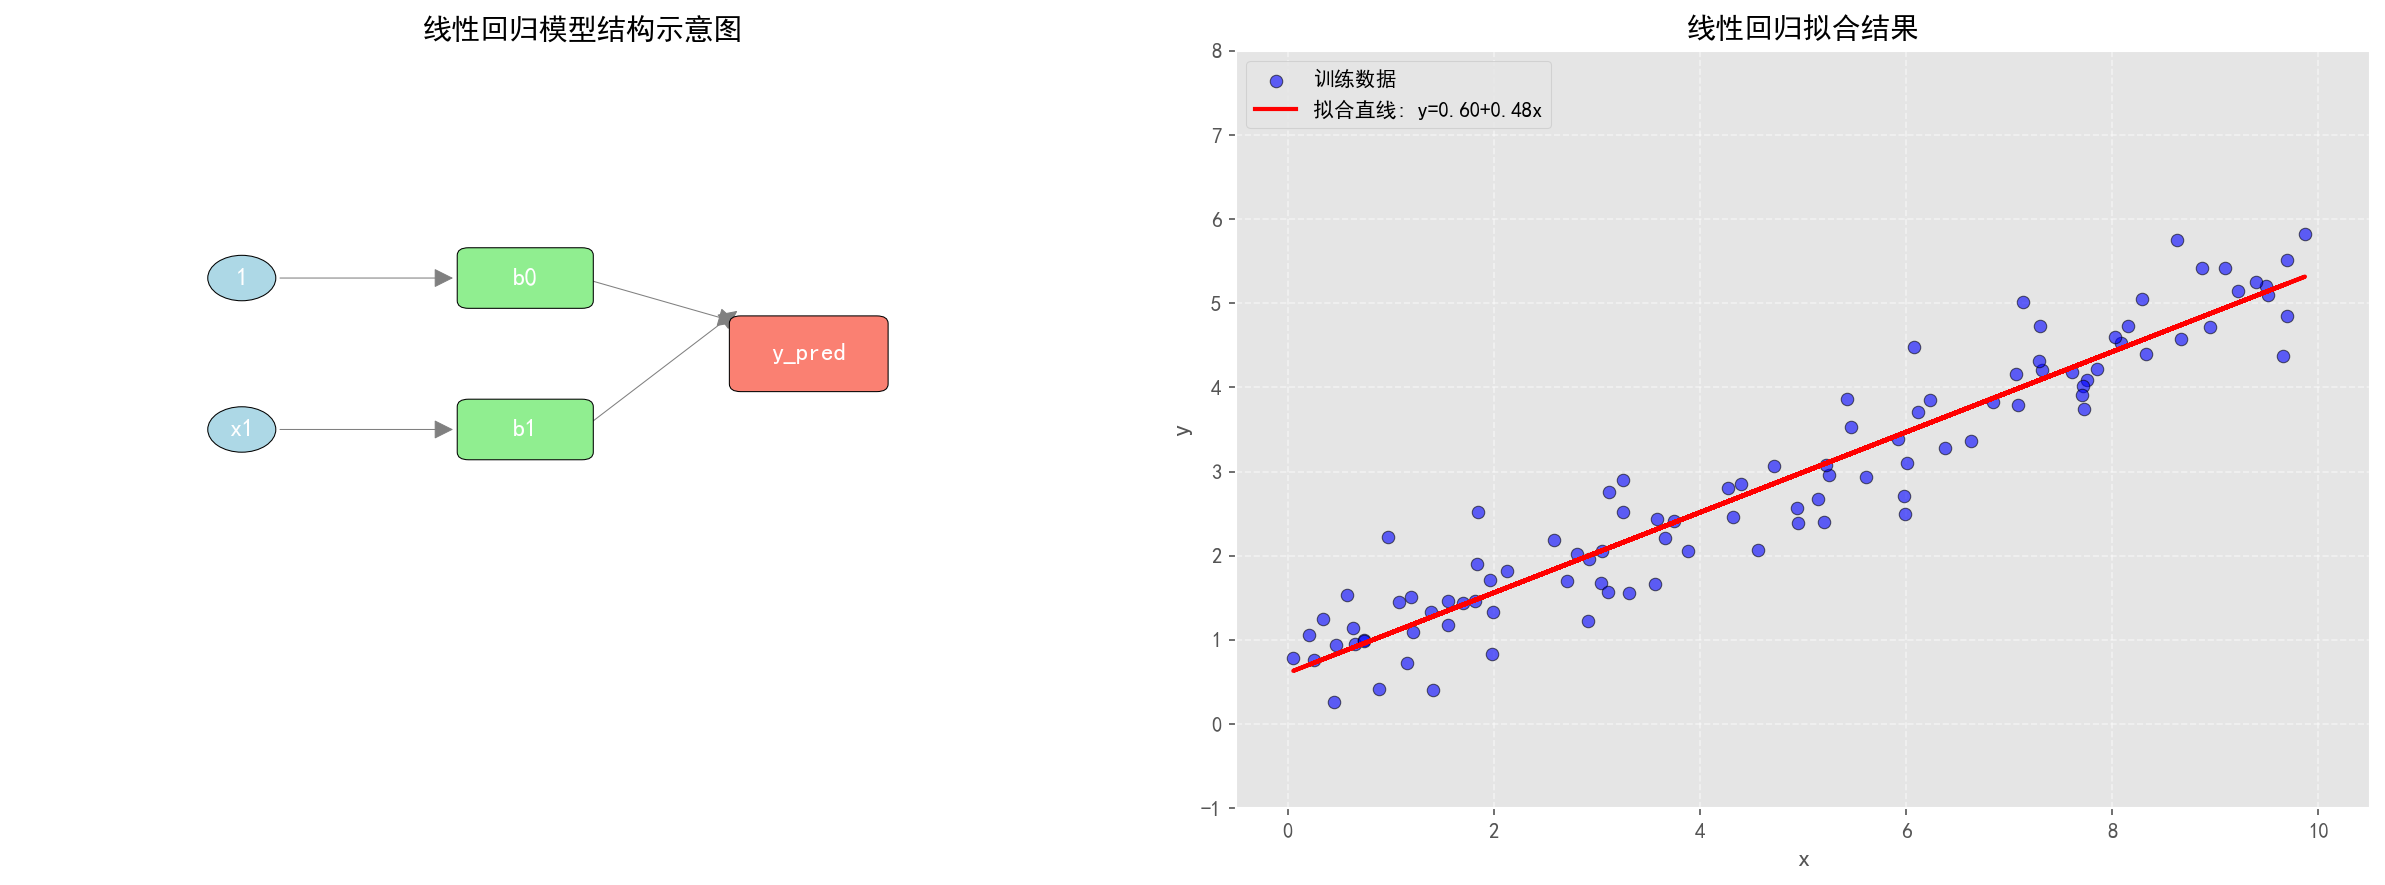

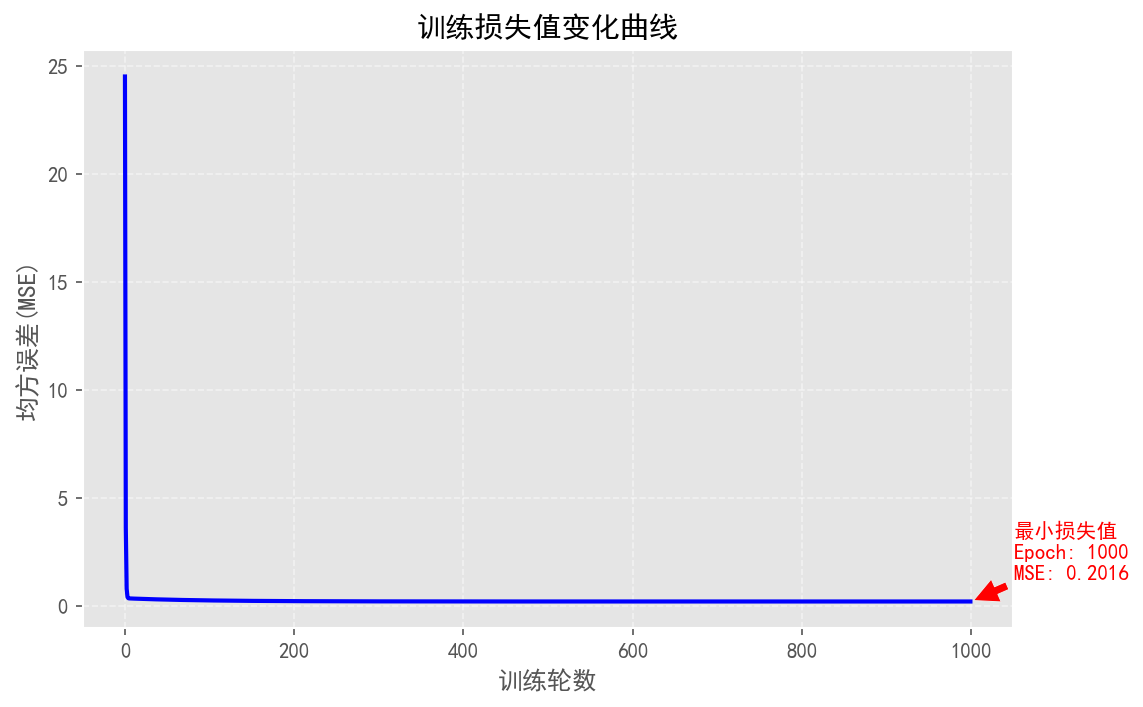


所有文件已保存到目录: d:\python_demo\coding\deepLearning\output


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch 
import warnings

# ================配置部分==================
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于显示中文标签
# plt.rcParams['axes.unicode_minus'] = False # 解决负号显示为方块的问题
# plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示为方块的问题
warnings.filterwarnings("ignore")  # 忽略警告信息
np.random.seed(42)  # 设置随机种子，确保结果可复现

n_samples = 100  # 样本数量
x = np.random.uniform(0, 10, n_samples)  # 在0到10之间均匀分布生成100个样本点
noise = np.random.normal(0, 0.5, n_samples)  # 生成噪声

# 生成目标变量y，真实关系为y = 0.5 + 0.5 * x + 噪声
y = 0.5 + 0.5 * x + noise

# =============数据预处理=============
X_train = x.reshape(-1, 1)  # 将输入特征x转换为二维数组
y_train = y.reshape(-1, 1)  # 将目标变量y转换为二维数组

# =============神经网络参数初始化=============
b0 = np.random.randn()  # 偏置项（截距）
b1 = np.random.randn()  # 权重项（斜率）

# ========定义神经网络函数========
def forward(x, b0, b1):
    """计算线性模型的预测值"""
    return b0 + b1 * x

def compute_loss(y_pred, y_true):
    """计算均方误差 (MSE)"""
    # 修复：原代码使用了 torch.mean，这里是 numpy 环境，应使用 np.mean
    return np.mean((y_pred - y_true) ** 2)

# =========训练超参数设置=========
learning_rate = 0.01
num_epochs = 1000
loss_history = []

# ==================开始训练====================
print("=" * 50)
print("开始训练线性回归模型...")
print("=" * 50)
print(f"初始参数：b0 = {b0:.4f}, b1 = {b1:.4f}")
print("=" * 50)

for epoch in range(num_epochs):
    # 1. 前向传播
    y_pred = forward(X_train, b0, b1)
    
    # 2. 计算损失值
    loss = compute_loss(y_pred, y_train)
    loss_history.append(loss)
    
    # 修复：移除 loss.backward()，因为这是 PyTorch 的方法，Numpy 需要手动计算梯度
    
    # 3. 反向传播计算梯度
    error = y_pred - y_train
    
    # 计算损失函数对 b0 的偏导数
    grad_b0 = 2 * np.mean(error)
    
    # 计算损失函数对 b1 的偏导数
    grad_b1 = 2 * np.mean(error * X_train)
    
    # 4. 参数更新：梯度下降
    b0 -= learning_rate * grad_b0
    b1 -= learning_rate * grad_b1
    
    # =============打印训练过程中的信息=============
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss:.4f}, b0: {b0:.4f}, b1: {b1:.4f}")

# ============训练结束===========
print("=" * 50)
print("训练完成！")
print(f"最终参数：b0 = {b0:.4f}, b1 = {b1:.4f}")
print(f"拟合方程：y = {b0:.4f} + {b1:.4f} * x")
print("=" * 50)

# ===========模型预测==========
predicted = forward(X_train, b0, b1)

# ==========创建输出目录===========
output_dir = "output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# =========== 创建可视化 ========
fig = plt.figure(figsize=(16, 6))

# 子图1：线性回归模型结构示意图
ax1 = plt.subplot(1, 2, 1)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')  # 关闭坐标轴显示

# ============控制输入层节点===========
input_y_pos = [7, 5]
input_labels = ['1', 'x1']
input_nodes = []

for i, (y_pos, label) in enumerate(zip(input_y_pos, input_labels)):
    # 创建圆形补丁
    circle = plt.Circle((2, y_pos), 0.3, color='lightblue', ec='black', zorder=2)
    # 修复：原代码这里写的是 ax2.add_patch，此时 ax2 未定义，应为 ax1
    ax1.add_patch(circle)
    ax1.text(2, y_pos, label, fontsize=12, ha='center', va='center', zorder=4, color='white')
    # 修复：append 只能接受一个参数，需要加括号变成元组
    input_nodes.append((2, y_pos))

# ===========绘制参数节点===========
param_pos = [(4.5, 7, 'b0'), (4.5, 5, 'b1')]
param_nodes = []

for x_pos, y_pos, label in param_pos:
    ellipse = FancyBboxPatch((x_pos - 0.5, y_pos - 0.3), 1, 0.6, boxstyle="round,pad=0.1", 
                             fc="lightgreen", ec="black", zorder=2)
    ax1.add_patch(ellipse)
    ax1.text(x_pos, y_pos, label, fontsize=12, ha='center', va='center', zorder=4, color='white', weight='bold')
    param_nodes.append((x_pos, y_pos))

# ===========控制输出节点=============
output_x, output_y = 7, 6
output_box = FancyBboxPatch((output_x - 0.6, output_y - 0.4), 1.2, 0.8, 
                            boxstyle="round,pad=0.1", fc="salmon", ec="black", zorder=2)
ax1.add_patch(output_box)
ax1.text(output_x, output_y, 'y_pred', fontsize=12, ha='center', va='center', zorder=4, color='white', weight='bold')

# ===========绘制连接线=============
# 修复：原代码使用 FancyBboxPatch 绘制箭头是错误的，应使用 FancyArrowPatch
# 从输入节点到参数
arrow1 = FancyArrowPatch((2.3, 7), (3.9, 7), arrowstyle='-|>', mutation_scale=20, color='gray', zorder=1)
ax1.add_patch(arrow1)

arrow2 = FancyArrowPatch((2.3, 5), (3.9, 5), arrowstyle='-|>', mutation_scale=20, color='gray', zorder=1)
ax1.add_patch(arrow2)

# 从参数到输出
arrow3 = FancyArrowPatch((5.0, 7), (6.4, 6.4), arrowstyle='-|>', mutation_scale=20, color='gray', zorder=1)
ax1.add_patch(arrow3)

arrow4 = FancyArrowPatch((5.0, 5), (6.4, 6.6), arrowstyle='-|>', mutation_scale=20, color='gray', zorder=1)
ax1.add_patch(arrow4)

ax1.set_title('线性回归模型结构示意图', fontsize=14)

# 子图2：训练数据与拟合直线
ax2 = plt.subplot(1, 2, 2)
ax2.scatter(x, y, alpha=0.6, color='blue', edgecolor='k', linewidth=0.5, zorder=3, label='训练数据')

# ============绘制拟合曲线========
# 修复：原代码 label 参数重复了，这里合并
ax2.plot(x, predicted, color='red', linewidth=2, zorder=4, label=f'拟合直线: y={b0:.2f}+{b1:.2f}x')

ax2.grid(True, linestyle='--', alpha=0.5, zorder=1)
ax2.set_xlabel('x', fontsize=12, weight='bold')
ax2.set_ylabel('y', fontsize=12, weight='bold')
ax2.set_title('线性回归拟合结果', fontsize=14)
ax2.legend(fontsize=10, loc='upper left')
ax2.set_xlim(-0.5, 10.5)
ax2.set_ylim(-1, 8)

plt.tight_layout()
# 保存图像
# plt.savefig(os.path.join(output_dir, 'linear_regression_result.png'), dpi=300)
print("可视化图像已保存到输出目录。")

# ===============绘制训练损失函数===============
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='blue', linewidth=2)
plt.xlabel('训练轮数', fontsize=12, weight='bold')
plt.ylabel('均方误差(MSE)', fontsize=12, weight='bold')
plt.title('训练损失值变化曲线', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# ===================添加最小的损失值标记=================
min_loss = min(loss_history)
min_epoch = loss_history.index(min_loss) + 1

plt.annotate(f'最小损失值\nEpoch: {min_epoch}\nMSE: {min_loss:.4f}',
             xy=(min_epoch, min_loss),
             xytext=(min_epoch + 50, min_loss + 1),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=10, color='red', weight='bold')

# plt.savefig(os.path.join(output_dir, 'training_loss_curve.png'), dpi=300)
plt.show()

# ================打印最终信息=============
print(f"\n所有文件已保存到目录: {os.path.abspath(output_dir)}")

正在生成训练数据...
Epoch [100/1000], Loss: 0.2637, Accuracy: 0.9200
Epoch [200/1000], Loss: 0.2608, Accuracy: 0.9200
Epoch [300/1000], Loss: 0.2586, Accuracy: 0.9200
Epoch [400/1000], Loss: 0.2566, Accuracy: 0.9200
Epoch [500/1000], Loss: 0.2545, Accuracy: 0.9200
Epoch [600/1000], Loss: 0.2526, Accuracy: 0.9200
Epoch [700/1000], Loss: 0.2508, Accuracy: 0.9200
Epoch [800/1000], Loss: 0.2490, Accuracy: 0.9200
Epoch [900/1000], Loss: 0.2473, Accuracy: 0.9200
Epoch [1000/1000], Loss: 0.2457, Accuracy: 0.9200
训练完成！
最终权重: [1.62273769 0.47791577 0.95115929 0.12656302 0.32029069]
最终偏置: 0.3146757326764215
最终准确率: 0.9200
✓ 训练历史图已保存: output\training_history.png

测试预测

测试样本特征:
  近期胜率: 0.70
  平均得分: 0.85
  历史交锋: 0.60
  球员状态: 0.75
  比赛重要性: 0.80

预测结果: 胜利
胜利概率: 94.15%
失败概率: 5.85%

✓ 网络架构图已保存: output\sports_prediction_network.png

批量预测示例

样本 1: 胜利概率 = 96.21% (预测胜利)

样本 2: 胜利概率 = 88.80% (预测胜利)

样本 3: 胜利概率 = 81.92% (预测胜利)


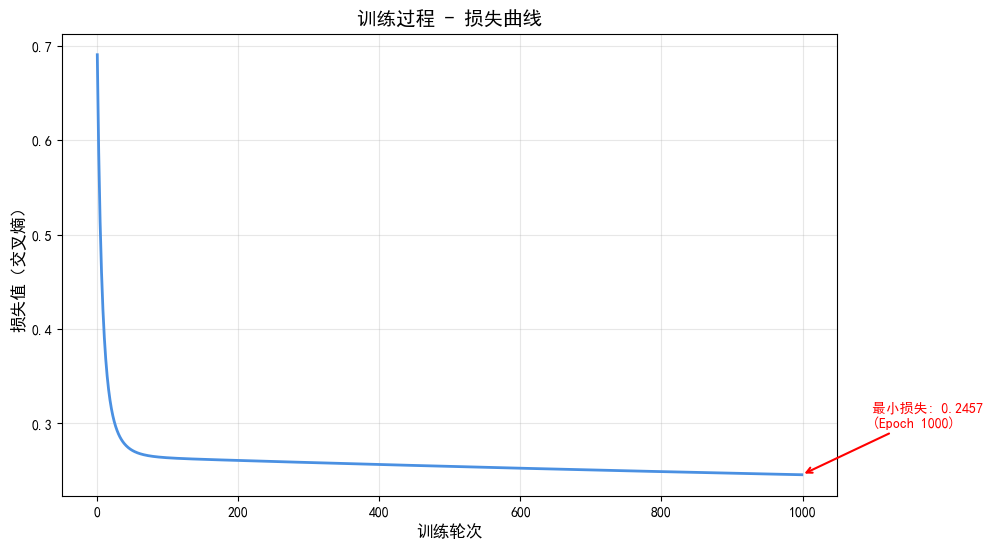

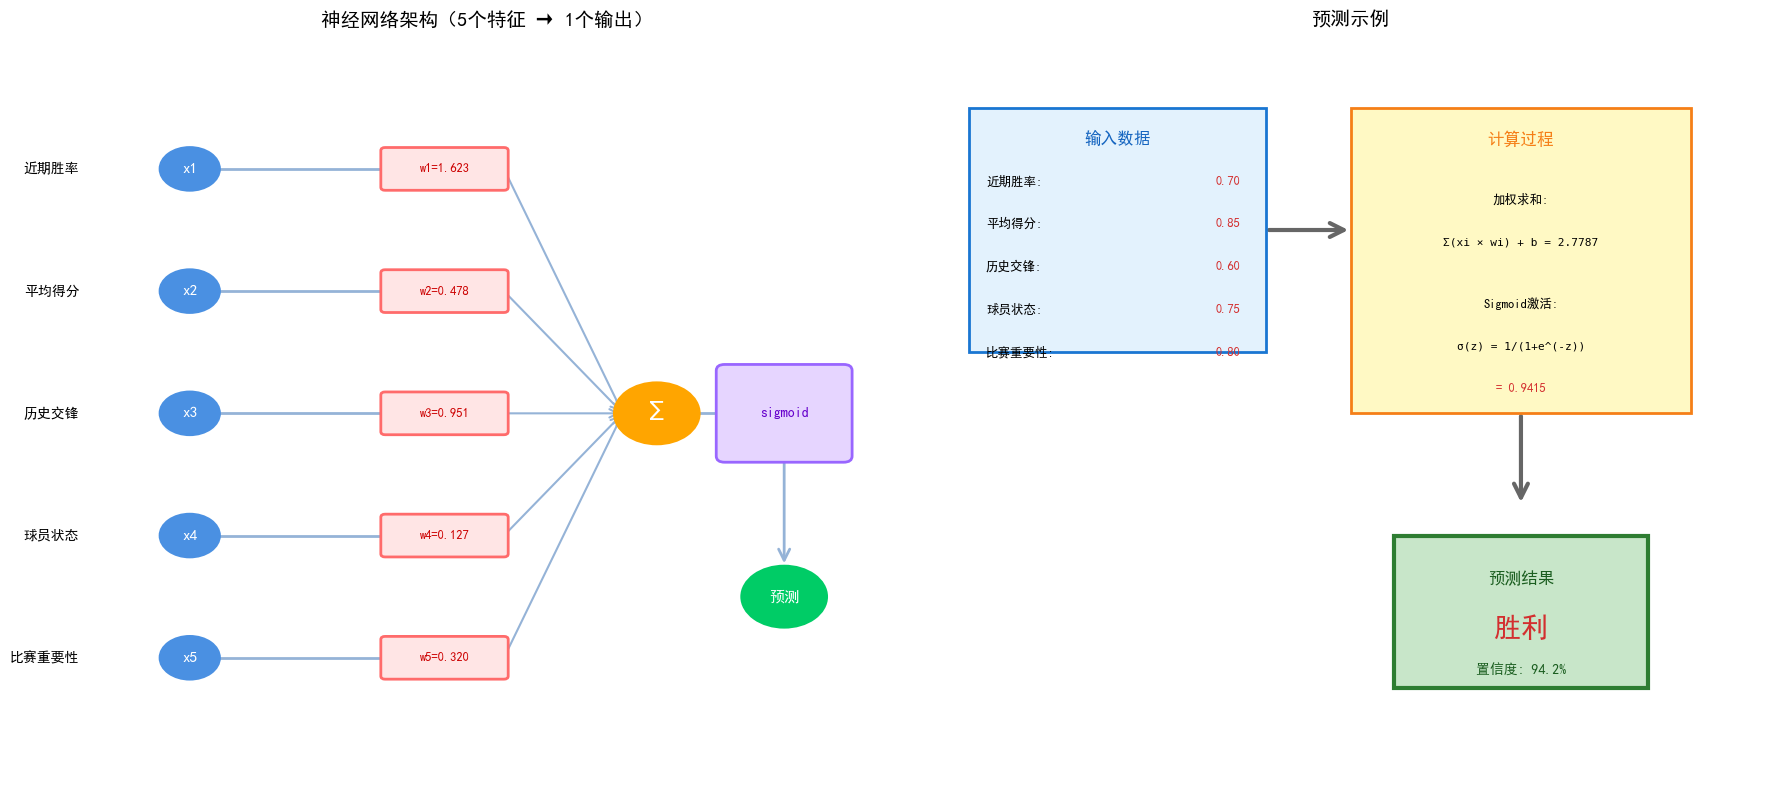


所有文件已保存到 output 文件夹


In [11]:
#体育比赛预测网络系统
#功能：基于历史数据预测比赛结果
#使用二分类神经网络， 输出胜利概率
#====================导入必要的库====================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, FancyArrowPatch, Rectangle
import os
import warnings
from sklearn.metrics import accuracy_score

# plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示为方
warnings.filterwarnings("ignore")  # 忽略警告信息

#==============神经网络定义=============
class SportPredictor:
    """
    体育比赛预测神经网络系统
    功能：基于历史数据预测比赛结果
    """
    def __init__(self, n_features=5, learning_rate=0.01):
        """初始化预测器，设置网络的基本参数
        参数说明：
        n_features: 输入特征的数量
        learning_rate: 学习率
        """
        #保存特征数量，后续用于权重的初始化和计算
        self.n_features = n_features  # 输入特征数量
        #保存学习率，用于梯度下降时的参数更新
        self.learning_rate = learning_rate  # 学习率
        # 初始化权重和偏置
        self.weights = np.random.randn(n_features) * 0.01  # 小随机数初始化权重
        self.bias = 0.0  # 偏置初始化为0
        self.losses = []  # 用于记录训练过程中的损失值
    
    def sigmoid(self, x):
        """
        Sigmoid激活函数，将输入映射到0-1之间
        公式：sigmoid(x) = 1 / (1 + exp(-x))
        参数：x:输入值
        返回：激活后的输出值
        """
        #先使用clip函数限制x的范围，防止溢出[-500, 500]
        #然后计算sigmoid函数值，1 / (1 + exp(-x))
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def predicted(self, X):
        """
        使用训练好的模型进行预测
        参数：x:输入特征数组，形状为(n_samples, n_features)
        n_samples:样本数量, n_features:特征数量

        返回：预测的胜利概率，形状为(n_samples,)
        """
        #第一步：计算线性组合 z = x · weights + bias
        z = np.dot(X, self.weights) + self.bias
        # 第二步：应用sigmoid激活函数，得到预测概率
        return self.sigmoid(z)
    
    def train(self, X, y, epochs=1000, verbose=True):
        """
        训练神经网络模型
        参数：
        X:输入特征数组，形状为(n_samples, n_features)
        y:真实标签数组，形状为(n_samples,)
        epochs:训练轮数
        verbose:是否打印训练过程信息
        """
        n_samples = X.shape[0]  # 样本数量
        
        for epoch in range(epochs):
            # 前向传播：计算预测值
            y_pred = self.predicted(X)
            
            # 计算损失值（使用二元交叉熵损失函数）
            # 公式：-mean(y * log(y_pred) + (1 - y) * log(1 - y_pred))
            loss = -np.mean(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))
            self.losses.append(loss)
            
            # 反向传播：计算梯度
            error = y_pred - y  # 预测误差
            dw = np.dot(X.T, error) / n_samples  # 权重梯度
            db = np.mean(error)  # 偏置梯度
            
            # 更新参数：梯度下降
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # 打印训练过程信息
            if verbose and (epoch + 1) % 100 == 0:
                #准确率计算
                accuracy = np.mean((y_pred >= 0.5) == y)
                print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

        #==============训练结束，打印信息=============
        if verbose:
            print("训练完成！")
            print(f"最终权重: {self.weights}")
            print(f"最终偏置: {self.bias}")
            #计算最终准确率
            final_accuracy = np.mean((y_pred >= 0.5) == y) #y_pred >=0.5为预测为1的样本 == y为真实标签
            print(f"最终准确率: {final_accuracy:.4f}")

#=============== 数据生成 ==============
def generate_sample_data(n_samples=100):
    """
    生成用于训练和测试的合成体育比赛数据
    参数：n_samples:样本数量
    返回：特征数组X和标签数组y
    特征说明：
    1. 客队近10场比赛胜率（0-1之间的浮点数）
    2. 客队平均得分（归一化0-1之间的浮点数）
    3. 主队历史胜率（0-1之间的浮点数）
    4. 客队球员状态评分（0-1之间的浮点数）
    5. 比赛重要系数（0-1之间的浮点数）
    """
    np.random.seed(42)  # 设置随机种子，确保结果可复现
    # 随机生成特征数据，假设有5个特征
    # 特征1：客队近10场比赛胜率
    recent_win_rate = np.random.uniform(0.3, 0.9, n_samples)
    # 特征2：客队平均得分（归一化0-1之间的浮点数）
    avg_score = np.random.uniform(0.5, 1.0, n_samples)
    # 特征3：主队历史胜率
    historical_win_rate = np.random.uniform(0.4, 0.95, n_samples)
    # 特征4：客队球员状态评分（0-1之间的浮点数）
    player_form = np.random.uniform(0.4, 1.0, n_samples)
    # 特征5：比赛重要系数（0-1之间的浮点数）
    match_importance = np.random.uniform(0.2, 1.0, n_samples)
    #============合并特征矩阵=========
    #column_stack函数将各个特征数组按列堆叠，形成最终的特征矩阵X
    X = np.column_stack([recent_win_rate, avg_score, historical_win_rate, player_form, match_importance])
    #============生成标签(基于特征的加权组合)=========
    #定义真实的权重，用于生成标签
    #胜率权重最大为0.4， 比赛权重最小为0.05
    true_weights = np.array([0.4, 0.2, 0.25, 0.1, 0.05])
    #计算加权和
    liner_combination = np.dot(X, true_weights)
    #添加随机噪声
    noise = np.random.normal(0, 0.05, n_samples)
    #生成二分类标签，阈值为0.5， 则标签为1，否则为0
    #astype(float)将布尔值转化为浮点数）
    y = (liner_combination + noise > 0.5).astype(float)
    return X, y

# ==================== 网络架构可视化函数 ====================
def visualize_network_architecture(model, sample_data, output_dir='output'):
    """
    可视化神经网络的架构和预测过程
    生成一张图，左边显示网络结构，右边显示实际预测示例

    参数:
        model: 已训练好的SportsPredictor模型对象
        sample_data: 一个样本的特征向量，用于演示预测过程
        output_dir: 图片保存的目录路径，默认为'output'
    """

    # 创建一个新的图形对象，大小为18英寸宽×8英寸高
    fig = plt.figure(figsize=(18, 8))

    # ==================== 左图：网络结构图 ====================
    # 创建第1个子图（1行2列布局中的第1个）
    ax1 = plt.subplot(1, 2, 1)
    # 设置x轴显示范围为0到10
    ax1.set_xlim(0, 10)
    # 设置y轴显示范围为0到12
    ax1.set_ylim(0, 12)
    # 关闭坐标轴显示，使图形更简洁美观
    ax1.axis('off')

    # 定义特征的中文名称，用于显示在图中
    feature_names = [
        '近期胜率',  # 特征1
        '平均得分',  # 特征2
        '历史交锋',  # 特征3
        '球员状态',  # 特征4
        '比赛重要性'  # 特征5
    ]

    # ========== 绘制输入层节点 ==========
    # 在y轴上等间距分布5个位置，从10到2
    input_y_positions = np.linspace(10, 2, 5)
    # 遍历每个输入节点的位置和名称
    for i, (y_pos, name) in enumerate(zip(input_y_positions, feature_names)):
        # 创建输入节点的圆形
        # 圆心在(1.5, y_pos)，半径0.35，蓝色填充
        circle = Circle((1.5, y_pos), 0.35, color='#4A90E2',
                        edgecolor='#2C5F8D',  # 深蓝色边框
                        linewidth=2,  # 边框宽度2
                        zorder=3)  # 图层顺序3（在上层）
        # 将圆形添加到子图中
        ax1.add_patch(circle)
        # 在圆心位置添加特征编号文本（x1, x2, ...）
        ax1.text(1.5, y_pos, f'x{i + 1}',  # i+1使编号从1开始
                 ha='center',  # 水平居中对齐
                 va='center',  # 垂直居中对齐
                 fontsize=11,  # 字体大小11
                 color='white',  # 白色字体
                 weight='bold',  # 粗体
                 zorder=4)  # 图层顺序4（在圆形上方）
        # 在节点左侧添加特征名称标签
        ax1.text(0.2, y_pos, name,
                 ha='right',  # 右对齐（靠近圆形）
                 va='center',  # 垂直居中
                 fontsize=10,  # 字体大小10
                 weight='bold')  # 粗体

    # ========== 绘制权重节点 ==========
    # 权重节点与输入节点的y坐标相同
    weight_y_positions = np.linspace(10, 2, 5)
    # 遍历每个权重的位置和数值
    for i, (y_pos, weight) in enumerate(zip(weight_y_positions, model.weights)):
        # 创建权重显示框（圆角矩形）
        # 左下角坐标(3.8, y_pos-0.3)，宽1.4，高0.6
        box = FancyBboxPatch((3.8, y_pos - 0.3), 1.4, 0.6,
                             boxstyle="round,pad=0.05",  # 圆角样式
                             edgecolor='#FF6B6B',  # 红色边框
                             facecolor='#FFE5E5',  # 浅红色填充
                             linewidth=2,  # 边框宽度
                             zorder=3)  # 图层顺序
        # 将权重框添加到子图中
        ax1.add_patch(box)
        # 在框中心显示权重值，格式为"w1=0.123"
        ax1.text(4.5, y_pos, f'w{i + 1}={weight:.3f}',  # 保留3位小数
                 ha='center',  # 水平居中
                 va='center',  # 垂直居中
                 fontsize=9,  # 字体大小9
                 color='#CC0000',  # 深红色字体
                 weight='bold',  # 粗体
                 zorder=4)  # 图层顺序

        # 绘制从输入节点到权重框的连接线
        # 从(1.85, y_pos)到(3.8, y_pos)的直线
        ax1.plot([1.85, 3.8], [y_pos, y_pos],
                 color='#95B3D7',  # 浅蓝色
                 linewidth=2,  # 线宽2
                 zorder=1)  # 图层顺序1（在底层）

    # ========== 绘制求和节点（Σ）==========
    # 创建求和节点的圆形，圆心在(7, 6)，半径0.5
    sum_node = Circle((7, 6), 0.5,
                      color='#FFA500',  # 橙色填充
                      edgecolor='#CC7700',  # 深橙色边框
                      linewidth=2,  # 边框宽度
                      zorder=3)  # 图层顺序
    # 将求和节点添加到子图中
    ax1.add_patch(sum_node)
    # 在圆心显示求和符号Σ
    ax1.text(7, 6, 'Σ',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=20,  # 大字体
             color='white',  # 白色
             weight='bold',  # 粗体
             zorder=4)  # 图层顺序

    # ========== 绘制权重到求和节点的箭头 ==========
    # 遍历每个权重节点的y坐标
    for y_pos in weight_y_positions:
        # 创建从权重框到求和节点的箭头
        arrow = FancyArrowPatch((5.2, y_pos),  # 起点（权重框右边）
                                (6.6, 6),  # 终点（求和节点左边）
                                arrowstyle='->',  # 箭头样式
                                mutation_scale=15,  # 箭头大小
                                color='#95B3D7',  # 浅蓝色
                                linewidth=1.5,  # 线宽
                                zorder=1)  # 图层顺序
        # 将箭头添加到子图中
        ax1.add_patch(arrow)

    # ========== 绘制Sigmoid激活函数框 ==========
    # 创建Sigmoid激活函数的显示框
    sigmoid_box = FancyBboxPatch((7.8, 5.3), 1.4, 1.4,
                                 boxstyle="round,pad=0.1",  # 圆角样式
                                 edgecolor='#9966FF',  # 紫色边框
                                 facecolor='#E6D5FF',  # 浅紫色填充
                                 linewidth=2,  # 边框宽度
                                 zorder=3)  # 图层顺序
    # 将Sigmoid框添加到子图中
    ax1.add_patch(sigmoid_box)
    # 在框中心显示"sigmoid"文本
    ax1.text(8.5, 6, 'sigmoid',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=10,  # 字体大小
             color='#6600CC',  # 深紫色
             weight='bold',  # 粗体
             zorder=4)  # 图层顺序

    # 绘制从求和节点到Sigmoid框的连接线
    ax1.plot([7.5, 7.8], [6, 6],  # 从(7.5,6)到(7.8,6)
             color='#95B3D7',  # 浅蓝色
             linewidth=2,  # 线宽2
             zorder=1)  # 图层顺序

    # ========== 绘制输出节点 ==========
    # 创建输出节点的圆形，圆心在(8.5, 3)，半径0.5
    output_circle = Circle((8.5, 3), 0.5,
                           color='#00CC66',  # 绿色填充
                           edgecolor='#009944',  # 深绿色边框
                           linewidth=2,  # 边框宽度
                           zorder=3)  # 图层顺序
    # 将输出节点添加到子图中
    ax1.add_patch(output_circle)
    # 在圆心显示"预测"文本
    ax1.text(8.5, 3, '预测',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=11,  # 字体大小
             color='white',  # 白色字体
             weight='bold',  # 粗体
             zorder=4)  # 图层顺序

    # 绘制从Sigmoid框到输出节点的箭头
    arrow = FancyArrowPatch((8.5, 5.3),  # 起点（Sigmoid框下方）
                            (8.5, 3.5),  # 终点（输出节点上方）
                            arrowstyle='->',  # 箭头样式
                            mutation_scale=20,  # 箭头大小
                            color='#95B3D7',  # 浅蓝色
                            linewidth=2,  # 线宽
                            zorder=1)  # 图层顺序
    # 将箭头添加到子图中
    ax1.add_patch(arrow)

    # 设置左图的标题
    ax1.set_title('神经网络架构（5个特征 → 1个输出）',
                  fontsize=14,  # 字体大小14
                  weight='bold',  # 粗体
                  pad=15)  # 标题与图的间距

    # ==================== 右图：实际预测示例 ====================
    # 创建第2个子图（1行2列布局中的第2个）
    ax2 = plt.subplot(1, 2, 2)
    # 设置x轴显示范围为0到10
    ax2.set_xlim(0, 10)
    # 设置y轴显示范围为0到12
    ax2.set_ylim(0, 12)
    # 关闭坐标轴显示
    ax2.axis('off')

    # ========== 绘制输入数据显示框 ==========
    # 创建矩形框用于显示输入数据
    # 左下角(0.5, 7)，宽3.5，高4
    data_box = Rectangle((0.5, 7), 3.5, 4,
                         facecolor='#E3F2FD',  # 浅蓝色填充
                         edgecolor='#1976D2',  # 蓝色边框
                         linewidth=2,  # 边框宽度
                         zorder=2)  # 图层顺序
    # 将矩形框添加到子图中
    ax2.add_patch(data_box)

    # 在框顶部显示"输入数据"标题
    ax2.text(2.25, 10.5, '输入数据',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=12,  # 字体大小12
             weight='bold',  # 粗体
             color='#1565C0')  # 深蓝色

    # ========== 显示具体的输入数据值 ==========
    # 遍历特征名称和样本数据
    for i, (name, value) in enumerate(zip(feature_names, sample_data)):
        # 计算当前特征显示的y坐标，从上到下依次递减
        y_pos = 9.8 - i * 0.7  # 每个特征间隔0.7
        # 显示特征名称（左对齐）
        ax2.text(0.7, y_pos, f'{name}:',
                 ha='left',  # 左对齐
                 va='center',  # 垂直居中
                 fontsize=9,  # 字体大小9
                 weight='bold')  # 粗体
        # 显示特征值（右对齐），保留2位小数
        ax2.text(3.7, y_pos, f'{value:.2f}',
                 ha='right',  # 右对齐
                 va='center',  # 垂直居中
                 fontsize=9,  # 字体大小
                 color='#D32F2F',  # 红色
                 weight='bold')  # 粗体

    # ========== 绘制箭头（从输入到计算）==========
    # 创建从输入框到计算框的箭头
    arrow = FancyArrowPatch((4, 9),  # 起点（输入框右侧）
                            (5, 9),  # 终点（计算框左侧）
                            arrowstyle='->',  # 箭头样式
                            mutation_scale=25,  # 箭头大小
                            color='#666',  # 灰色
                            linewidth=3,  # 线宽3
                            zorder=1)  # 图层顺序
    # 将箭头添加到子图中
    ax2.add_patch(arrow)

    # ========== 绘制计算过程显示框 ==========
    # 创建矩形框用于显示计算过程
    calc_box = Rectangle((5, 6), 4, 5,  # 左下角(5,6)，宽4，高5
                         facecolor='#FFF9C4',  # 浅黄色填充
                         edgecolor='#F57F17',  # 黄色边框
                         linewidth=2,  # 边框宽度
                         zorder=2)  # 图层顺序
    # 将计算框添加到子图中
    ax2.add_patch(calc_box)

    # 在框顶部显示"计算过程"标题
    ax2.text(7, 10.5, '计算过程',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=12,  # 字体大小
             weight='bold',  # 粗体
             color='#F57F17')  # 黄色

    # ========== 执行实际计算并显示结果 ==========
    # 第一步：计算加权和
    # z = w1*x1 + w2*x2 + w3*x3 + w4*x4 + w5*x5 + bias
    z = np.dot(sample_data, model.weights) + model.bias
    # 第二步：通过Sigmoid函数得到最终预测概率
    prediction = model.sigmoid(z)

    # 显示"加权求和"标题
    ax2.text(7, 9.5, f'加权求和:',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=9,  # 字体大小
             weight='bold')  # 粗体
    # 显示加权求和的公式和结果
    ax2.text(7, 8.8, f'Σ(xi × wi) + b = {z:.4f}',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=8,  # 字体大小
             family='monospace')  # 等宽字体

    # 显示"Sigmoid激活"标题
    ax2.text(7, 7.8, f'Sigmoid激活:',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=9,  # 字体大小
             weight='bold')  # 粗体
    # 显示Sigmoid函数公式
    ax2.text(7, 7.1, f'σ(z) = 1/(1+e^(-z))',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=8,  # 字体大小
             family='monospace')  # 等宽字体

    # 显示最终预测概率，保留4位小数
    ax2.text(7, 6.4, f'= {prediction:.4f}',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=9,  # 字体大小
             color='#D32F2F',  # 红色
             weight='bold')  # 粗体

    # ========== 绘制箭头（从计算到结果）==========
    # 创建从计算框到结果框的箭头
    arrow2 = FancyArrowPatch((7, 6),  # 起点（计算框下方）
                             (7, 4.5),  # 终点（结果框上方）
                             arrowstyle='->',  # 箭头样式
                             mutation_scale=25,  # 箭头大小
                             color='#666',  # 灰色
                             linewidth=3,  # 线宽
                             zorder=1)  # 图层顺序
    # 将箭头添加到子图中
    ax2.add_patch(arrow2)

    # ========== 绘制预测结果显示框 ==========
    # 创建矩形框用于显示最终预测结果
    result_box = Rectangle((5.5, 1.5), 3, 2.5,  # 位置和大小
                           facecolor='#C8E6C9',  # 浅绿色填充
                           edgecolor='#2E7D32',  # 绿色边框
                           linewidth=3,  # 边框宽度
                           zorder=2)  # 图层顺序
    # 将结果框添加到子图中
    ax2.add_patch(result_box)

    # 根据预测概率判断结果文本：>0.5为"胜利"，否则为"失败"
    result_text = "胜利" if prediction > 0.5 else "失败"
    # 计算置信度：如果预测胜利则置信度=预测概率，否则=1-预测概率
    confidence = prediction if prediction > 0.5 else 1 - prediction

    # 显示"预测结果"标题
    ax2.text(7, 3.3, '预测结果',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=12,  # 字体大小
             weight='bold',  # 粗体
             color='#1B5E20')  # 深绿色
    # 显示预测结果文本（"胜利"或"失败"）
    ax2.text(7, 2.5, result_text,
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=20,  # 大字体
             weight='bold',  # 粗体
             color='#D32F2F')  # 红色
    # 显示置信度百分比
    ax2.text(7, 1.8, f'置信度: {confidence:.1%}',
             ha='center',  # 水平居中
             va='center',  # 垂直居中
             fontsize=10,  # 字体大小
             color='#1B5E20')  # 深绿色

    # 设置右图的标题
    ax2.set_title('预测示例',
                  fontsize=14,  # 字体大小
                  weight='bold',  # 粗体
                  pad=15)  # 标题间距

    # 自动调整子图布局，防止元素重叠
    plt.tight_layout()

    # ========== 保存图片 ==========
    # 检查输出目录是否存在
    if not os.path.exists(output_dir):
        # 如果不存在则创建目录
        os.makedirs(output_dir)
    # 构建完整的输出文件路径
    output_path = os.path.join(output_dir, 'sports_prediction_network.png')
    # 保存图片为PNG格式，分辨率300dpi，白色背景
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    # 打印保存成功的提示信息
    print(f'\n✓ 网络架构图已保存: {output_path}')


# ==================== 训练历史可视化函数 ====================
def plot_training_history(losses, output_dir='output'):
    """
    绘制训练过程中的损失曲线
    用于可视化模型的训练效果和收敛情况

    参数:
        losses: 损失值列表，每个元素是一个训练轮次的损失值
        output_dir: 图片保存目录，默认'output'
    """
    # 创建一个新的图形，大小为10×6英寸
    plt.figure(figsize=(10, 6))
    # 绘制损失曲线：x轴是轮次（自动从0开始），y轴是损失值
    plt.plot(losses,
             linewidth=2,  # 线宽2
             color='#4A90E2')  # 蓝色
    # 设置x轴标签
    plt.xlabel('训练轮次',
               fontsize=12,  # 字体大小
               weight='bold')  # 粗体
    # 设置y轴标签
    plt.ylabel('损失值（交叉熵）',
               fontsize=12,  # 字体大小
               weight='bold')  # 粗体
    # 设置图表标题
    plt.title('训练过程 - 损失曲线',
              fontsize=14,  # 字体大小
              weight='bold')  # 粗体
    # 显示网格线，透明度0.3
    plt.grid(True, alpha=0.3)

    # ========== 标注最小损失点 ==========
    # 找出损失列表中的最小值
    min_loss = min(losses)
    # 找出最小损失值对应的索引（轮次）
    min_idx = losses.index(min_loss)
    # 在图上添加箭头和文本标注
    plt.annotate(f'最小损失: {min_loss:.4f}\n(Epoch {min_idx + 1})',  # 标注文本
                 xy=(min_idx, min_loss),  # 箭头指向的点
                 xytext=(min_idx + 100, min_loss + 0.05),  # 文本框位置
                 arrowprops=dict(arrowstyle='->',  # 箭头样式
                                 color='red',  # 红色
                                 lw=1.5),  # 线宽
                 fontsize=10,  # 字体大小
                 color='red')  # 红色文字

    # 构建完整的输出文件路径
    output_path = os.path.join(output_dir, 'training_history.png')
    # 保存图片为PNG格式，分辨率300dpi
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    # 打印保存成功的提示信息
    print(f'✓ 训练历史图已保存: {output_path}')


# ==================== 主程序入口 ====================
# 当脚本被直接运行时（而不是被导入时），执行以下代码
if __name__ == '__main__':
    # ========== 第一步：生成训练数据 ==========
    # 打印提示信息
    print("正在生成训练数据...")
    # 调用函数生成100个训练样本
    # X_train: 特征矩阵(100×5)
    # y_train: 标签向量(100,)
    X_train, y_train = generate_sample_data(n_samples=100)

    # ========== 第二步：创建并训练模型 ==========
    # 创建SportsPredictor对象
    # n_features=5: 5个输入特征
    # learning_rate=0.1: 学习率0.1
    model = SportPredictor(n_features=5, learning_rate=0.1)
    # 训练模型
    # epochs=1000: 训练1000轮
    # verbose=True: 打印训练信息
    model.train(X_train, y_train, epochs=1000, verbose=True)

    # ========== 第三步：绘制训练历史 ==========
    # 将模型记录的损失历史绘制成曲线图
    plot_training_history(model.losses)

    # ========== 第四步：测试预测 ==========
    # 打印分隔线和标题
    print("\n" + "=" * 60)
    print("测试预测")
    print("=" * 60)

    # 创建一个测试样本（5个特征值）
    test_sample = np.array([0.70, 0.85, 0.60, 0.75, 0.80])  # 5个特征
    # 使用模型进行预测
    # reshape(1, -1)将一维数组转换为二维数组(1×5)
    # [0]取出第一个（也是唯一一个）预测结果
    prediction = model.predicted(test_sample.reshape(1, -1))[0]

    # 打印测试样本的特征信息
    print(f"\n测试样本特征:")
    print(f"  近期胜率: {test_sample[0]:.2f}")  # 保留2位小数
    print(f"  平均得分: {test_sample[1]:.2f}")
    print(f"  历史交锋: {test_sample[2]:.2f}")
    print(f"  球员状态: {test_sample[3]:.2f}")
    print(f"  比赛重要性: {test_sample[4]:.2f}")
    # 打印预测结果：概率>0.5判断为"胜利"，否则为"失败"
    print(f"\n预测结果: {'胜利' if prediction > 0.5 else '失败'}")
    # 打印胜利概率（百分比形式）
    print(f"胜利概率: {prediction:.2%}")
    # 打印失败概率（1减去胜利概率）
    print(f"失败概率: {(1 - prediction):.2%}")

    # ========== 第五步：可视化网络架构 ==========
    # 调用函数生成网络架构图，使用测试样本作为示例
    visualize_network_architecture(model, test_sample)

    # ========== 第六步：批量预测示例 ==========
    # 打印分隔线和标题
    print("\n" + "=" * 60)
    print("批量预测示例")
    print("=" * 60)
    # 创建3个测试样本
    test_samples = np.array([
        [0.85, 0.90, 0.75, 0.85, 0.90],  # 样本1：强队（特征值都很高）
        [0.50, 0.60, 0.45, 0.55, 0.50],  # 样本2：中等队伍
        [0.30, 0.40, 0.35, 0.45, 0.40],  # 样本3：弱队（特征值都较低）
    ])

    # 对3个样本进行批量预测
    predictions = model.predicted(test_samples)

    # 遍历每个样本的预测结果
    for i, pred in enumerate(predictions):
        # 打印样本编号、预测概率和预测结果
        print(f"\n样本 {i + 1}: 胜利概率 = {pred:.2%} ({'预测胜利' if pred > 0.5 else '预测失败'})")

    # 显示所有已创建的图形窗口
    plt.show()

    # 打印最终提示信息
    print("\n所有文件已保存到 output 文件夹")
    print("=" * 60)



        

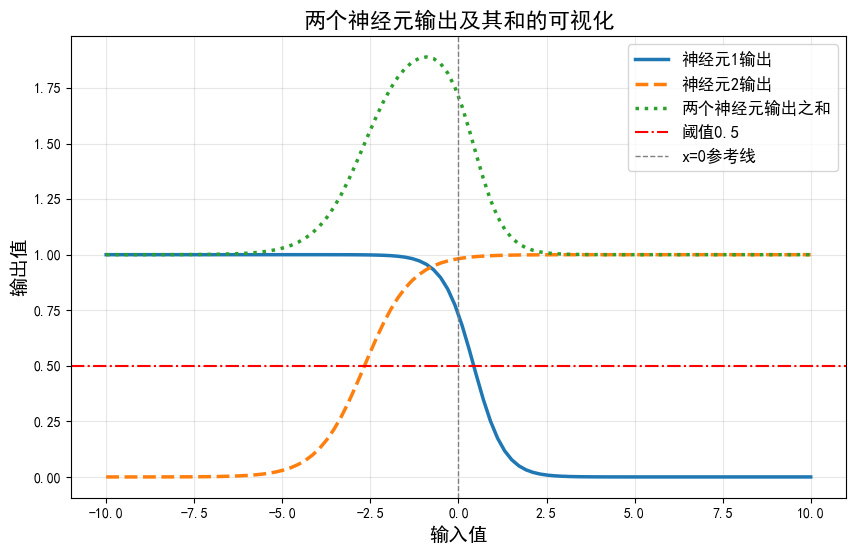

In [ ]:
from turtle import color
from pyparsing import line


plt.rcParams['font.sans-serif'] = ['SimHei', 'Times New Roman']  # 设置字体以支持中文显示
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
warnings.filterwarnings("ignore")  # 忽略警告信息
#=====================定义sigmoid函数======================
def sigmoid(x):
    """
    计算输入x的Sigmoid激活值
    参数：x:输入值，可以是标量或numpy数组
    返回：Sigmoid激活值
    公式：σ(x) = 1 / (1 + exp(-x))
    """
    return 1 / (1 + np.exp(-x)) #exp为绝对值函数， 为什么时-x？因为sigmoid函数的定义就是这样的
#=====================定义零个神经元参数==================
#神经元1参数
x1 = np.linspace(-10, 10, 100)  # 输入范围从-10到10，共100个点, linspace函数生成等间距的数值序列
w1 = -2.3 # 权重
b1 = 1.0  # 偏置
#神经元2参数
x2 = np.linspace(-10, 10, 100)
w2 = 1.5  # 权重
b2 = 4 # 偏置
#===============计算神经元的输出===============
y1 = sigmoid(w1 * x1 + b1)  # 神经元1输出
y2 = sigmoid(w2 * x2 + b2)  # 神经元2输出
#两个神经元输出的和
y_sum = y1 + y2
#=================控制图形==============
plt.figure(figsize=(10, 6))
plt.plot(x1, y1, label='神经元1输出', color='#1f77b4', lw=2.5, linestyle='-')  # 神经元1曲线
# 绘制神经元2输出曲线
plt.plot(x2, y2, label='神经元2输出', color='#ff7f0e', lw=2.5, linestyle='--')  # 神经元2曲线
# 绘制两个神经元输出的和曲线
plt.plot(x1, y_sum, label='两个神经元输出之和', color='#2ca02c', lw=2.5, linestyle=':')  # 输出和曲线
#添加水平参数
plt.axhline(y=0.5, color='red', linestyle='-.', lw=1.5, label='阈值0.5')  # 阈值线
#添加垂直参考线
plt.axvline(x=0, color='gray', linestyle='--', lw=1, label='x=0参考线')  # x=0参考线
# 添加图例
plt.legend(fontsize=12)
# 添加标题和轴标签
plt.title('两个神经元输出及其和的可视化', fontsize=16, weight='bold')
plt.xlabel('输入值', fontsize=14, weight='bold')
plt.ylabel('输出值', fontsize=14, weight='bold')
# 显示网格
plt.grid(True, alpha=0.3)
# 保存图形到output文件夹
# output_dir = 'output'
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)
# output_path = os.path.join(output_dir, 'two_neurons_output.png')
# plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
# print(f'✓ 两个神经元输出图已保存: {output_path}')
# 显示图形  
plt.show()


## Tanh 激活函数详解

### 什么是 Tanh 函数？
Tanh 全称为 Hyperbolic Tangent。它的数学公式为：$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$
核心特性：
- 取值范围（Range）： $(-1, 1)$。这意味着无论输入多大或多小，输出永远在 -1 到 1 之间。
- 形状： S 形曲线（Sigmoid shape），但穿过原点 $(0,0)$。
- 零中心化（Zero-centered）： 这是它与 Sigmoid 函数最大的区别。Tanh 的输出均值接近 0。

### Tanh 在深度学习中有什么用？  
#### A. 解决“Zigzag”优化路径（相比 Sigmoid 的优势）  
 早期的神经网络常使用 Sigmoid 函数（输出范围 $0$ 到 $1$）。因为 Sigmoid 的输出恒为正，这会导致导致后续层的输入也恒为正。在反向传播计算梯度时，这会引起权重更新方向出现“捆绑效应”（要么全增加，要么全减少），导致梯度下降像“之”字形（Zigzag）一样震荡，收敛缓慢。  
 Tanh 的作用： 因为 Tanh 的输出有正有负（零中心化），它可以让梯度的收敛方向更加直接和高效。在大多数需要使用 S 形曲线的场景下，Tanh 通常优于 Sigmoid。  

#### B. 循环神经网络（RNN/LSTM/GRU）的核心组件  
 这是 Tanh 目前最主流的战场。
 - 防止数值爆炸： 在处理序列数据时（如时间序列预测、NLP），数据会在网络中循环传播。如果使用 ReLU（$x>0$ 时输出无限大），经过多次循环乘积后，数值容易爆炸(Exploding Gradient/Value)。
 - 信息流控制： LSTM（长短期记忆网络）和 GRU 内部的状态更新门控通常使用 Tanh。它将状态值限制在 $(-1, 1)$ 之间，既保留了非线性，又维持了数值的稳定性。    
  
 #### C. 特定的输出层需求  
 如果你的模型任务是回归问题，且目标值的范围通过数据预处理被归一化到了 $[-1, 1]$ 之间，那么在输出层直接使用 Tanh 是非常合适的。
 - 例子： 在生成对抗网络（GAN）中，生成器（Generator）的最后一层常用 Tanh，将生成的像素值映射回 $[-1, 1]$ 以匹配预处理后的图像数据。

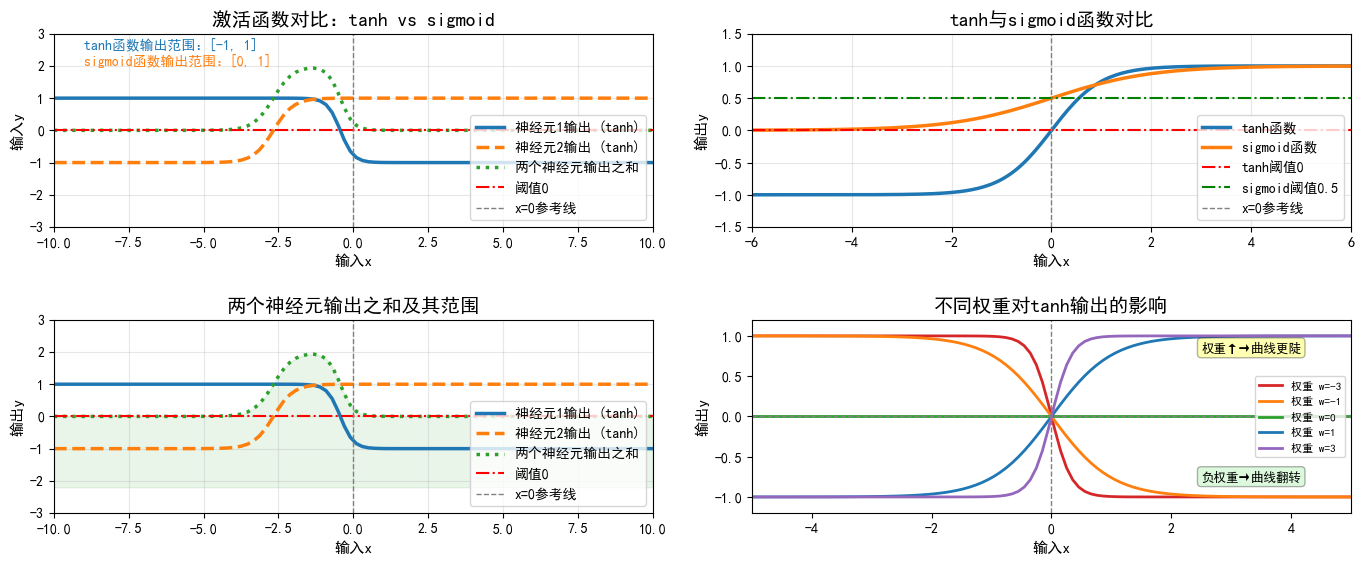

In [6]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Times New Roman']  # 设置字体以支持中文显示
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
#忽略字体警告
warnings.filterwarnings("ignore")  # 忽略警告信息

#==================定义tanh激活函数===============
def tanh(x):
    """
    计算输入x的tanh激活值
    参数：x:输入值，可以是标量或numpy数组
    返回：tanh激活值
    公式：tanh(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))
    """
    return np.tanh(x) #使用numpy的tanh函数计算双曲正切值
#==================定义两个神经元参数===============
#神经元1的参数
x1 = np.linspace(-10, 10, 100)  # 输入范围从-10到10，共100个点
w1 = -2.3  # 权重
b1 = -1.0  # 偏置
#神经元2的参数
x2 = np.linspace(-10, 10, 100)
w2 = 1.5  # 权重
b2 = 4.0  # 偏置
#================计算神经元的输出===============
#神经源1的输出y1 = tanh(w1 * x1 + b1)
y1 = tanh(w1 * x1 + b1)  # 神经元1输出
#神经元2的输出y2 = tanh(w2 * x2 + b2)
y2 = tanh(w2 * x2 + b2)  # 神经元2输出
#计算神经元输出和线性组合
#展示神经网络的非线性特性
y_sum = y1 + y2
#================绘制对比图================
def sigmod(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # 防止溢出
#创建对比数据
x_compare = np.linspace(-6, 6, 200)
y_tanh = np.tanh(x_compare)
y_sigmoid = sigmod(x_compare)

#==============创建综合图形==============
fig = plt.figure(figsize=(14, 6))
#==============子图1：神经元输出对比图=============
ax1 = plt.subplot(2, 2, 1)
ax1.plot(x1, y1, label='神经元1输出 (tanh)', color='#1f77b4', lw=2.5, linestyle='-')  # 神经元1曲线
ax1.plot(x2, y2, label='神经元2输出 (tanh)', color='#ff7f0e', lw=2.5, linestyle='--')  # 神经元2曲线
ax1.plot(x1, y_sum, label='两个神经元输出之和', color='#2ca02c', lw=2.5, linestyle=':')  # 输出和曲线
ax1.axhline(y=0, color='red', linestyle='-.', lw=1.5, label='阈值0')  # 阈值线
ax1.axvline(x=0, color='gray', linestyle='--', lw=1, label='x=0参考线')  # x=0参考线
ax1.legend(fontsize=10, loc='lower right')
ax1.set_xlabel('输入x', fontsize=11, weight='bold')
ax1.set_ylabel('输入y', fontsize=11, weight='bold')
ax1.set_title('激活函数对比：tanh vs sigmoid', fontsize=14, weight='bold')
ax1.set_xlim(-10, 10)
ax1.set_ylim(-3, 3)
#添加文本
ax1.text(-9, 2.5, 'tanh函数输出范围：[-1, 1]', fontsize=10, color='#1f77b4')
ax1.text(-9, 2.0, 'sigmoid函数输出范围：[0, 1]', fontsize=10, color='#ff7f0e')
ax1.grid(True, alpha=0.3)
#==============子图2：tanh与sigmoid对比图=============
ax2 = plt.subplot(2, 2, 2)
ax2.plot(x_compare, y_tanh, label='tanh函数', color='#1f77b4', lw=2.5)
ax2.plot(x_compare, y_sigmoid, label='sigmoid函数', color='#ff7f0e', lw=2.5)
ax2.axhline(y=0, color='red', linestyle='-.', lw=1.5, label='tanh阈值0')  # tanh阈值线
ax2.axhline(y=0.5, color='green', linestyle='-.', lw=1.5, label='sigmoid阈值0.5')  # sigmoid阈值线
ax2.axvline(x=0, color='gray', linestyle='--', lw=1, label='x=0参考线')  # x=0参考线
ax2.legend(fontsize=10)
ax2.set_xlabel('输入x', fontsize=11, weight='bold')
ax2.set_ylabel('输出y', fontsize=11, weight='bold')
ax2.set_title('tanh与sigmoid函数对比', fontsize=14, weight='bold')
ax2.set_xlim(-6, 6)
ax2.set_ylim(-1.5, 1.5)
ax2.grid(True, alpha=0.3)
#===============子图3：神经元输出和图=============
ax3 = plt.subplot(2, 2, 3)
ax3.plot(x1, y1, label='神经元1输出 (tanh)', color='#1f77b4', lw=2.5, linestyle='-')  # 神经元1曲线
ax3.plot(x2, y2, label='神经元2输出 (tanh)', color='#ff7f0e', lw=2.5, linestyle='--')  # 神经元2曲线
ax3.plot(x1, y_sum, label='两个神经元输出之和', color='#2ca02c', lw=2.5, linestyle=':')  # 输出和曲线
#添加水平参考线
ax3.axhline(y=0, color='red', linestyle='-.', lw=1.5, label='阈值0')  # 阈值线
ax3.axvline(x=0, color='gray', linestyle='--', lw=1, label='x=0参考线')  # x=0参考线
#填充区域显示输出和的范围
ax3.fill_between(x1, -2.2, y_sum, alpha=0.1, color='#2ca02c')
ax3.grid(True, alpha=0.3)
ax3.set_xlabel('输入x', fontsize=11, weight='bold')
ax3.set_ylabel('输出y', fontsize=11, weight='bold')
ax3.set_title('两个神经元输出之和及其范围', fontsize=14, weight='bold')
ax3.legend(fontsize=10, loc='lower right')
ax3.set_xlim(-10, 10)
ax3.set_ylim(-3, 3)
#================子图4：参数效果分析=============
ax4 = plt.subplot(2, 2, 4)
#显示不同的权重效果
x_demo = np.linspace(-5, 5, 100)
y_demo = np.linspace(-5, 5, 100)
weights = [-3, -1, 0, 1, 3]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
for w, color in zip(weights, colors):
    y_param = tanh(w * x_demo)
    ax4.plot(x_demo, y_param, label=f'权重 w={w}', color=color, lw=2)
ax4.axhline(y=0, color='gray', linestyle='--', lw=1)  # y=0参考线
ax4.axvline(x=0, color='gray', linestyle='--', lw=1)  # x=0参考线
ax4.set_xlabel('输入x', fontsize=11, weight='bold')
ax4.set_ylabel('输出y', fontsize=11, weight='bold')
ax4.set_title('不同权重对tanh输出的影响', fontsize=14, weight='bold')
ax4.legend(fontsize=8)

ax4.set_xlim(-5, 5)
ax4.set_ylim(-1.2, 1.2)
# 添加说明文本
ax4.text(x=2.5, y=0.8, s='权重↑→曲线更陡', fontsize=9,
bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
ax4.text(x=2.5, y=-0.8, s='负权重→曲线翻转', fontsize=9,
bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

# 调整整体布局
plt.tight_layout (pad=2.0)
# end for
# #显示图形
plt.show()



### ReLU 激活函数详解
**ReLU (Rectified Linear Unit)** 是目前深度学习（尤其是 CNN）中最常用、也是极其重要的激活函数。

虽然它的公式非常简单——**“大于0保留，小于0变0”**，但它在深度学习的历史上具有革命性的地位，主要因为它解决了深层网络“训练难”的问题。

公式：



$$f(x) = \max(0, x)$$

图像如下所示：

以下是 ReLU 在深度学习中的四大核心作用：

#### 1. 引入非线性 (Non-linearity) —— 赋予网络“灵魂”

这是所有激活函数的共同作用，但必须强调。

- **没有激活函数：** 无论网络有多少层，如果不加激活函数，每一层都只是简单的线性变换（乘法和加法）。多层线性变换叠加后，本质上还是一个线性变换。网络只能解决简单的线性问题（比如画一条直线把红豆和绿豆分开）。
- **有了 ReLU：** 它引入了“折线”。通过无数个折线的组合，神经网络可以逼近任意复杂的曲线或形状。这让网络有了拟合复杂数据（如图像分类、语言处理）的能力。

#### 2. 缓解“梯度消失”问题 (Solving Vanishing Gradient) —— 核心贡献

在 ReLU 流行之前，大家常用 **Sigmoid** 或 **Tanh** 函数。

- **旧方法的痛点：** Sigmoid 把输入压缩到 (0, 1) 之间。当输入很大或很小时，函数的导数（梯度）几乎为 0。在深层网络的反向传播中，这些很小的梯度连乘，传到前面几层时就变成了 0，导致网络**停止学习**（这就是梯度消失）。
- **ReLU 的优势：**
  - 只要输入 $x > 0$，ReLU 的导数恒为 **1**。
  - 这意味着梯度可以无损地传回前面的层，让深层网络（Deep Network）变得容易训练。这是 ResNet 等超深网络能够出现的前提之一。

#### 3. 计算效率极高 (Computational Efficiency) —— 速度快

- **Sigmoid/Tanh：** 需要计算指数 $e^x$，涉及复杂的浮点运算，计算成本高。
- **ReLU：** 只需要一个简单的阈值判断 `if x > 0 return x else return 0`。在训练海量数据时，这能节省巨大的计算资源，加速收敛。

#### 4. 稀疏性 (Sparsity) —— 特征筛选

- **原理：** 当输入小于 0 时，ReLU 输出为 0。这意味着在任何时刻，网络中通常只有一部分神经元被“激活”（输出非零），其他的处于“静默”状态。
- **作用：** 这模拟了人脑的工作方式（人脑不会同时激活所有神经元）。稀疏激活性有助于减少参数的相互依赖，防止过拟合，并让模型学习到的特征更具有鲁棒性。

------

#### ⚠️ 唯一的缺点：Dead ReLU 问题

虽然 ReLU 很强，但它有个副作用。

- **现象：** 如果某个神经元的输入是个很大的负数，经过 ReLU 后变成 0，且梯度也为 0。在反向传播时，这个神经元的权重无法更新。
- **后果：** 这个神经元可能永远“死”了，以后不管输入什么数据，它都只会输出 0，对网络没有任何贡献。

> **解决方案：** 为了解决这个问题，后来提出了 **Leaky ReLU** 或 **PReLU**，它们在 $x < 0$ 的部分不再是 0，而是给一个很小的斜率（比如 $0.01x$），让梯度能稍微传过去一点，保证神经元“活着”。

### 三大激活函数对比总结
| **特性**     | **Sigmoid**  | **Tanh**                 | **ReLU**            |
| :------------: | :------------: | :------------------------: | :-------------------: |
| **数学公式** | $\sigma(x) = \frac{1}{1 + e^{-x}}$ | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $f(x) = \max(0, x)$ |
| **numpy 实现** | `1 / (1 + np.exp(-x))` | `np.tanh(x)`           | `np.maximum(0, x)`   |
| **输出范围:值域** | $(0, 1)$     | **$(-1, 1)$**            | $[0, +\infty)$      |
| **零中心化** | 否           | **是**（主要优势）       | 否                  |
| **梯度消失** | 严重         | **严重**（在两端饱和时） | 无（在正区间）      |
| **主要应用** | 二分类输出层 | **RNN/LSTM，GAN 生成器** | CNN，大多数深层网络 |
| **图像形状**|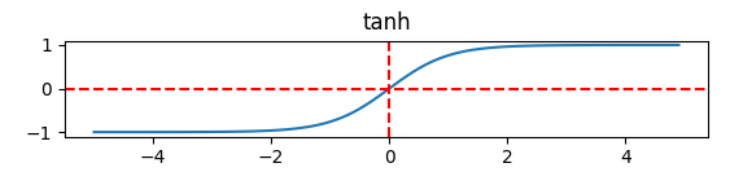|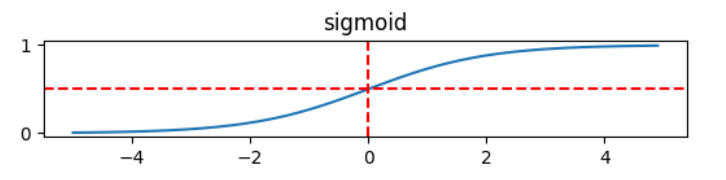|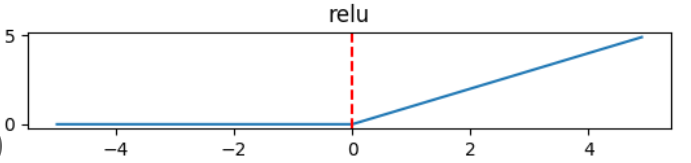|


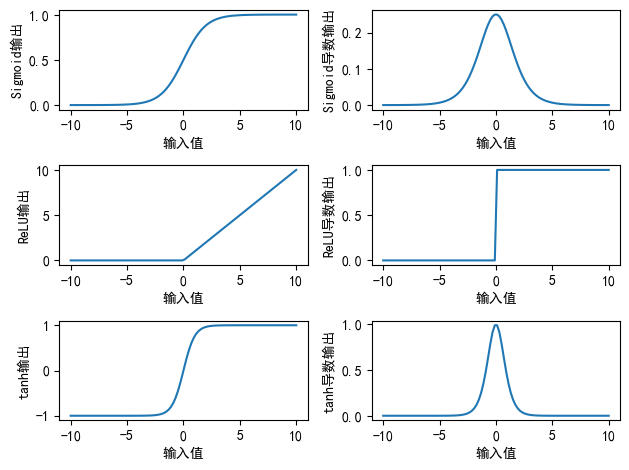

In [ ]:
import matplotlib.pyplot as plt
from torch import sigmoid_
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'Times New Roman']  # 设置字体以支持中文显示
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

#创建一个新的图形，大小为12×6英寸
inputs = np.array(np.linspace(-10, 10, 100))  #输入范围从-10到10，共100个点
#定义sigmoid函数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

#计算输入值对应的sigmoid输出
sigmoid_outputs = sigmoid(inputs)
#创建子图，并绘制sigmoid函数曲线
plt.subplot(3, 2, 1)
plt.plot(inputs, sigmoid_outputs)
plt.xlabel('输入值')
plt.ylabel('Sigmoid输出')

#定义sigmoid函数的导数
def sigmoid_derivative(x):
    sig = 1.0/(1.0 + np.exp(-x)) #计算sigmoid值
    return sig * (1 - sig) #计算导数值：为什么是sig * (1 - sig)？因为这是sigmoid函数导数的定义
#创建子图，并绘制sigmoid函数导数曲线
plt.subplot(3, 2, 2)
sigmod_de_outputs = sigmoid_derivative(inputs) #计算导数输出
plt.plot(inputs, sigmod_de_outputs)
plt.xlabel('输入值')
plt.ylabel('Sigmoid导数输出')

#定义Relu激活函数
def relu(x):
    return np.maximum(0, x)
#创建子图，并绘制Relu函数曲线
plt.subplot(3, 2, 3)
plt.plot(inputs, relu(inputs))
plt.xlabel('输入值')
plt.ylabel('ReLU输出')
#定义Relu函数的导数
def relu_derivative(x):
    return np.where(x > 0, 1, 0) #大于0时导数为1，否则为0
#计算输入值对应的Relu导数输出
relu_de_outputs = relu_derivative(inputs)
#绘制3x3子图中的第4个子图
plt.subplot(3, 2, 4)
plt.plot(inputs, relu_de_outputs)
plt.xlabel('输入值')
plt.ylabel('ReLU导数输出')
#定义tanh激活函数
def tanh(x):
    return np.tanh(x)
#创建子图，并绘制tanh函数曲线
plt.subplot(3, 2, 5)
plt.plot(inputs, tanh(inputs))
plt.xlabel('输入值')
plt.ylabel('tanh输出')
#定义tanh函数的导数
def tanh_derivative(x):
    return 1.0 - np.tanh(x)**2
#计算输入值对应的tanh导数输出
tanh_de_outputs = tanh_derivative(inputs)
#绘制3x3子图中的第6个子图
plt.subplot(3, 2, 6)
plt.plot(inputs, tanh_de_outputs)
plt.xlabel('输入值')
plt.ylabel('tanh导数输出')
#自动调整子图布局，防止元素重叠
plt.tight_layout()
#显示图形
plt.show()

In [ ]:
#ModelTrainer.py, 全连接
from networkx import current_flow_betweenness_centrality
import pandas as pd
from sklearn.base import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import torch
#导入pytorch的神经网络模块，包含各种层和激活函数
import torch.nn as nn
import numpy as np
import random
import os
#导入joblib库，用于模型的保存和加载
import joblib
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

def setup_seed(seed):
    """
    设置随机种子，确保结果可复现
    参数:
        seed: 整数类型的随机种子
    """
    torch.manual_seed(seed) # 设置CPU随机种子
    #设置GPU随机种子（如果使用GPU）
    torch.cuda.manual_seed_all(seed)
    #设置numpy随机种子
    np.random.seed(seed)
    #设置CUDNN的确定性模式
    torch.backends.cudnn.deterministic = True

# 调用函数，设置随机种子为42
setup_seed(42) 
class FCNModel(nn.Module): # 全连接神经网络模型
    """
    定义一个简单的全连接神经网络模型
    用于二分类任务

    """
    def __init__(self, input_size, hidden_sizes=[512, 256, 128, 64], output_size=1, dropout=0.2):
        """     
        参数：
        input_size: 输入特征的维度
        hidden_sizes: 隐藏层的神经元数量列表默认为[512, 256, 128, 64]
        output_size: 输出层的神经元数量，默认为1（用于二分类）
        dropout: Dropout层的丢弃概率，默认为0.2
        """
        super(FCNModel, self).__init__()
        # 创建空列表用于存储网络层
        layers = []
        #当前输入维度，初始为输入的特征维度
        current_size = input_size
        #遍历隐藏层的神经元数量列表
        for h_size in hidden_sizes:
            #添加线性层
            layers.append(nn.Linear(current_size, h_size))
            #添加添加SiLU激活函数层，也称为Swish激活函数
            layers.append(nn.SiLU())
            #添加批归一化层，加速训练收敛
            layers.append(nn.BatchNorm1d(h_size))
            #添加Dropout层
            layers.append(nn.Dropout(dropout))
            #更新当前输入维度为当前隐藏层的输出维度，以便下一层使用
            current_size = h_size

        #将所有的层组合成一个顺序容器
        self.feature_layers = nn.Sequential(*layers)
        #最终输出层，将最后的隐藏层映射到输出维度
        self.final = nn.Linear(current_size, output_size)
        #应用权重初始化方法到所层
        self.apply(self._init_weights)


    def _init_weights(self, m):
        """
        权重初始化方法
        参数:
            m: 神经网络层
        """
        if isinstance(m, nn.Linear):
            #使用Xavier均匀分布初始化线性层的权重
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                #将偏置初始化为0
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        定义前向传播过程
        参数:
            x: 输入数据张量
        返回:
            输出概率张量
        """
        return self.final(self.feature_layers(x))

class ModelTrainer:
    """
    模型训练器类
    用于训练、评估和保存全连接神经网络模型
    """
    def __init__(self, input_size, hidden_sizes=[512, 256, 128, 64], output_size=1, dropout=0.2, learning_rate=0.001,decice=None):
        """
        参数:
            input_size: 输入特征的维度
            hidden_sizes: 隐藏层的神经元数量列表，默认为[512, 256, 128, 64]
            output_size: 输出层的神经元数量，默认为1（用于二分类）
            dropout: Dropout层的丢弃概率，默认为0.2
            learning_rate: 学习率，默认为0.001
            device: 计算设备，默认为None（自动选择CPU或GPU）,为None时自动选择
        """
        self.device = torch.device('cuda' if torch.cuda.is_available() and decice=='cuda' else 'cpu')
        print(f'使用设备: {self.device}')
        #保存隐层参数
        self.hidden_sizes = hidden_sizes
        # 初始化全连接神经网络模型
        self.model = None
        #定义二分类交叉熵损失函数
        self.criterion = nn.BCEWithLogitsLoss()
        #定义Adam优化器
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        #初始化标准化器
        self.scaler = StandardScaler()
        #保存损失历史
        self.history = {'train_loss': [], 'val_loss': []}
        #初始化最佳验证损失为无穷大
        self.best_val_loss = float('inf')
    def train_from_numpy(self, X_train, y_train, val_split=0.1, batch_size=2048, epochs=100, lr=1e-3):
        """
        使用numpy数组训练模型
        参数:
            val_split: 验证集比例，默认为0.1
            batch_size: 批次大小，默认为2048
            epochs: 训练轮次，默认为100
            lr: 学习率，默认为1e-3

            X_train: 训练特征数据，numpy数组
            y_train: 训练标签数据，numpy数组
            X_val: 验证特征数据，numpy数组，默认为None
            y_val: 验证标签数据，numpy数组，默认为None
            epochs: 训练轮次，默认为100
            batch_size: 批次大小，默认为32
            verbose: 是否打印训练信息，默认为True
            save_path: 模型保存路径，默认为'model.pkl'
        """
        #归一化特征
        #使用StandardScaler进行标准化
        X_scaled = self.scaler.fit_transform(X_train)
        #将归一化后的数据转换为PyTorch张量
        X_tensor = torch.FloatTensor(X_scaled)
        #将目标标签转换为PyTorch张量，并调整形状为(-1, 1)
        y_tensor = torch.FloatTensor(y_train.reshape(-1, 1))
        
        #获取数据集总大小
        dataset_size = len(X_tensor)
        #计算验证机大小
        val_size = int(dataset_size * val_split)
        #计算训练集大小
        train_size = dataset_size - val_size
        #使用random_split随机划分训练集和验证机
        train_dataset, val_dataset = torch.utils.data.random_split(
            TensorDataset(X_tensor, y_tensor),
            [train_size, val_size]
        )
        #创建训练数据加载器，suffle=True打乱数据
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        #创建验证数据加载器，shuffle=False不打乱数据
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        #如果模型未创建
        if self.model is None:
            #创建FCNModel模型实例
            self.model = FCNModel(
                input_size=X_train.shape[1],
                hidden_sizes=self.hidden_sizes,
                output_size=1,
                dropout=0.2
            ).to(self.device)
        #调用训练器并返回训练结果
        return self._train_loop(train_loader, val_loader, epochs, lr)
    def _train_loop(self, train_loader, val_loader, epochs, lr):
        """
        训练循环
        参数:
            train_loader: 训练数据加载器
            val_loader: 验证数据加载器
            epochs: 训练轮次
            lr: 学习率
        返回:
            训练历史字典，包含训练损失和验证损失列表
        """
        #定义损失函数为均方误差，适合回归任务
        criterion = nn.MSELoss()
        #定义优化器为Adam优化器
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)
        #学习率调度器，减少学习率
        #ReduceLROnPlateau在验证损失不再改善时减少学习率
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
        #早停机制参数
        patience = 30  # 提前停止的耐心值
        # 早停计数器
        early_stop_counter = 0
        #开始训练循环
        for epoch in range(epochs):
            # 训练模式
            self.model.train()
            train_losses = []
            # 遍历训练数据加载器
            for X_batch, y_batch in train_loader:
                # 将数据移动到指定设备
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                # 前向传播
                outputs = self.model(X_batch)
                # 计算损失
                loss = criterion(outputs, y_batch)
                # 清零梯度
                optimizer.zero_grad()
                # 反向传播
                loss.backward()
                # 更新参数
                optimizer.step()
                # 记录训练损失
                train_losses.append(loss.item())
            # 计算平均训练损失
            avg_train_loss = np.mean(train_losses)
            # 验证模式
            self.model.eval()
            val_losses = []
            # 禁用梯度计算
            with torch.no_grad():
                # 遍历验证数据加载器
                for X_batch, y_batch in val_loader:
                    # 将数据移动到指定设备
                    X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                    # 前向传播
                    outputs = self.model(X_batch)
                    # 计算损失
                    loss = criterion(outputs, y_batch)
                    # 记录验证损失
                    val_losses.append(loss.item())
            # 计算平均验证损失
            avg_val_loss = np.mean(val_losses)
            # 调整学习率
            scheduler.step(avg_val_loss)
            # 打印训练信息
            print(f'Epoch [{epoch + 1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
            # 保存训练历史
            self.history['train_loss'].append(avg_train_loss)
            self.history['val_loss'].append(avg_val_loss)
            # 检查是否需要早停
            if avg_val_loss < self.best_val_loss:
                self.best_val_loss = avg_val_loss
                early_stop_counter = 0  # 重置计数器
                #保存当前最佳模型
                torch.save(self.model.state_dict(), 'best_climate_model.pth')
                joblib.dump(self.scaler, 'scaler.pkl')
                print("✓ 保存当前最佳模型(Epoch {}, Val Loss: {:.4f})".format(epoch + 1, avg_val_loss))

            else:
                early_stop_counter += 1
                #手动获取当前学习率并打印
                current_lr = optimizer.param_groups[0]['lr']
                #每10轮打印当前学习率
                #或者在第一论打印
                if epoch % 10 == 0 or epoch == 0:
                    print(f'当前学习率: {current_lr:.6f}, Tran: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}, LR: {current_lr:.6f}')
                if early_stop_counter >= patience:
                    print("验证损失未改善，提前停止训练。停止于Epoch {}".format(epoch + 1))
                    break  # 提前停止训练


        #加载最佳模型
        #加载验证损失最低时的模型参数
        self.model.load_state_dict(torch.load('best_climate_model.pth'))
        # 加载对应的Scaler
        self.scaler = joblib.load('scaler.pkl')
        print("✓ 加载最佳模型参数，验证损失: {:.4f}".format(self.best_val_loss))
        #返回训练历史
        return self.history
    def _validate(self, val_loader):
        """
        验证模型性能
        参数:
            val_loader: 验证数据加载器
        返回:
            平均验证损失
        """
        self.model.eval()  # 设置模型为评估模式
        val_losses = []
        with torch.no_grad():  # 禁用梯度计算
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                outputs = self.model(X_batch)
                loss = self.criterion(outputs, y_batch)
                val_losses.append(loss.item())
        avg_val_loss = np.mean(val_losses)
        return avg_val_loss

    def predict(self, X):
        """
        使用训练好的模型进行预测
        参数:
            X: 输入特征数据，numpy数组
        返回:
            预测结果，numpy数组
        """
        self.model.eval()  # 设置模型为评估模式
        # 归一化输入特征
        X_scaled = self.scaler.transform(X)
        X_tensor = torch.FloatTensor(X_scaled).to(self.device)
        with torch.no_grad():  # 禁用梯度计算
            outputs = self.model(X_tensor)
            predictions = torch.sigmoid(outputs).cpu().numpy()  # 使用sigmoid函数将输出转换为概率
        return predictions
    
    def load_model(self, model_path='best_climate_model.pth', scaler_path='scaler.pkl'):
        """
        加载保存的模型和Scaler
        参数:
            model_path: 模型文件路径
            scaler_path: Scaler文件路径
        """
        #加载模型参数
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"模型文件未找到: {model_path}")
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        #加载Scaler对象
        self.scaler = joblib.load(scaler_path)
        print(f"✓ 模型已加载: {model_path} 和 Scaler: {scaler_path}")

    def save_model(self, model_path='climate_model.path', scaler_path='scaler.pkl'):
        """
        保存模型和Scaler到文件
        参数:
            model_path: 模型文件路径
            scaler_path: Scaler文件路径
        """
        #保存模型参数
        torch.save(self.model.state_dict(), model_path)
        #保存Scaler对象
        joblib.dump(self.scaler, scaler_path)
        print(f"✓ 模型已保存: {model_path} 和 Scaler: {scaler_path}")


# =========================main.py 主程序==========================

plt.style.use('ggplot')  # 使用ggplot风格的图形
plt.rcParams['font.sans-serif'] = ['SimHei', 'Times New Roman']  # 设置字体以支持中文显示
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
#设置图像分辨率为150 DPI
plt.rcParams['figure.dpi'] = 150
def load_climate_data(path):
    """
    加载气候数据集
    参数:
        path: 数据文件路径
    返回:
        pandas DataFrame格式的气候数据:X_train, y_train, X_test, y_test划分好训练集和测试集
    """
    #打印正在读取文件路径信息
    print(f"正在读取数据文件: {path}")
    try:
        #使用默认分隔符读取CSV文件
        df = pd.read_csv(path)
        print(f"✓ 数据文件读取成功，数据集大小: {df.shape}")
    except Exception as e:
        print(f"读取数据文件时出错: {e}")
        raise e
    
    #检查列名是否符合规则
    #定义必须的列名
    required_cols = ['year', 'month', 'lat', 'lon', 'anomaly']
    #遍历必须的列名
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"数据文件缺少必要的列: {col}")
    #打印数据预览
    print("数据预览:")
    print(f"时间范围: {df['year'].min()} - {df['year'].max()}")
    print(f"月份范围: {df['month'].min()} - {df['month'].max()}")
    print(f"温度范围: {df['anomaly'].min():.2f} - {df['anomaly'].max():.2f}")
    print(f"经纬度范围: 纬度({df['lat'].min()} - {df['lat'].max()}), 经度({df['lon'].min()} - {df['lon'].max()})")    

    #将年月转换为日期格式
    df['temp_date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
    #按照时间排序（非常重要，保证训练集是时间顺序）
    #先按照日期排序，再按照经纬度排序
    df = df.sort_values(['temp_date', 'lat', 'lon'])
    #删除缺失值
    #记录原始数据的长度
    initial_len = len(df)
    #删除包含缺失值的行
    df = df.dropna()
    #打印删除缺失值的信息
    dropped = initial_len - len(df)
    if dropped > 0:
        print(f"✓ 删除缺失值: {dropped} 行，剩余数据: {len(df)} 行")
    #添加：异常值检测
    Q1 = df['anomaly'].quantile(0.25)
    Q3 = df['anomaly'].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df['anomaly'] < (Q1 - 1.5 * IQR)) | (df['anomaly'] > (Q3 + 1.5 * IQR))]
    #打印异常值信息
    print(f"检测到异常值: {len(outliers)} 行")
    
    #特种工程
    #创建新的特征列
    print("正在进行特征工程...")
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
    df['year_norm'] = (df['year'] - df['year'].min()) / (df['year'].max() - df['year'].min())
    print("✓ 特征工程完成。")

    #定义特征和目标
    features_cols = ['year_norm', 'month', 'lat', 'lon', 'sin_month', 'cos_month']
    #目标列为'anomaly'
    target_col = 'anomaly'
    X = df[features_cols].values
    y = df[target_col].values
    #打印特征和目标的形状
    print(f"特征形状: {X.shape}, 目标形状: {y.shape}")
    #划分训练集和测试集
    split_index = int(len(X) * 0.8)
    #划分数据集
    X_train, y_train, X_test, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
    #计算时间分割点
    #计算训练和测试集的索引
    split_idx = int(len(X) * 0.8)
    train_years = df.iloc[:split_idx]['year'].unique()
    test_years = df.iloc[split_idx:]['year'].unique()
    print(f"训练集时间范围: {train_years.min()} - {train_years.max()}")
    print(f"测试集时间范围: {test_years.min()} - {test_years.max()}")
    return X_train, y_train, X_test, y_test

def plot_loss_history(history):
    """
    绘制训练和验证损失历史
    参数:
        history: 训练历史字典，包含'train_loss'和'val_loss'列表
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    #创建epoch序列，从1开始到训练损失列表长度+1
    epochs  = range(1, len(history['train_loss']) + 1)
    #绘制训练损失曲线
    ax.plot(epochs, history['train_loss'], label='训练损失', color='#1f77b4', lw=2)
    #绘制验证损失曲线
    ax.plot(epochs, history['val_loss'], label='验证损失', color='#ff7f0e', lw=2)
    #添加图例
    ax.legend(fontsize=12)
    #添加标题和轴标签
    ax.set_title('训练和验证损失历史', fontsize=16, weight='bold')
    ax.set_xlabel('训练轮次', fontsize=14, weight='bold')
    ax.set_ylabel('损失值', fontsize=14, weight='bold')
    #显示网格
    ax.grid(True, alpha=0.3)
    #保存图形到output文件夹
    # output_dir = 'output'
    # if not os.path.exists(output_dir):
    #     os.makedirs(output_dir)
    # output_path = os.path.join(output_dir, 'loss_history.png')
    # plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='
    # print(f'✓ 损失历史图已保存: {output_path}')
    #显示图形
    plt.show()
def plot_prediction_results(y_test, y_pred, metrics):
    """
    绘制预测结果可视化 (2x2 布局)
    参数:
        y_test: 真实值数组
        y_pred: 预测值数组
        metrics: 包含评估指标的字典
    返回:
        fig: matplotlib 图形对象
    """
    # 创建 2×2 子图布局，总图形大小为 14×12 英寸
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # ============ 子图1: 散点图 (真实值 vs 预测值) ============
    # 获取第一个子图（左上角）
    ax1 = axes[0, 0]

    # 随机采样用于散点图
    # 设置采样大小：最多10000个点或测试集大小（取较小值）
    sample_size = min(10000, len(y_test))
    # 随机选择样本索引，不重复抽样
    sample_indices = np.random.choice(len(y_test), sample_size, replace=False)
    # 根据采样索引获取真实值
    y_test_scatter = y_test[sample_indices]
    # 根据采样索引获取预测值，并展平为一维数组
    y_pred_scatter = y_pred[sample_indices].flatten()

    # 绘制散点图：蓝色，透明度0.3，点大小10
    scatter = ax1.scatter(y_test_scatter, y_pred_scatter, alpha=0.3, s=10, c='blue')

    # 绘制理想线 (y=x)
    # 找到真实值和预测值的最小值
    min_val = min(y_test_scatter.min(), y_pred_scatter.min())
    # 找到真实值和预测值的最大值
    max_val = max(y_test_scatter.max(), y_pred_scatter.max())
    # 绘制从最小值到最大值的对角线（理想情况下预测值应等于真实值）
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal (y=x)')

    # 设置子图标题
    ax1.set_title('Actual vs Predicted Values', fontsize=14, fontweight='bold')
    # 设置 x 轴标签
    ax1.set_xlabel('Actual Temperature Anomaly (°C)', fontsize=11)
    # 设置 y 轴标签
    ax1.set_ylabel('Predicted Temperature Anomaly (°C)', fontsize=11)
    # 显示图例
    ax1.legend(loc='upper left', fontsize=10)
    # 显示网格
    ax1.grid(True, alpha=0.3)

    # 添加 R² 值标注
    # 在图的右下角（相对坐标0.95, 0.05）添加 R² 值文本框
    ax1.text(0.95, 0.05, f'R² = {metrics["r2"]:.4f}', transform=ax1.transAxes,
             fontsize=12, verticalalignment='bottom', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # ============ 子图2: 时间序列对比 (最近500个样本) ============
    # 获取第二个子图（右上角）
    ax2 = axes[0, 1]

    # 设置要显示的样本数：最多500个或测试集大小（取较小值）
    sample_size = min(500, len(y_test))
    # 获取测试集的最后 sample_size 个样本（最新的数据）
    y_test_sample = y_test[-sample_size:]
    # 获取对应的预测值，并展平
    y_pred_sample = y_pred[-sample_size:].flatten()
    # 创建 x 轴索引（0到样本数-1）
    x_axis = range(len(y_test_sample))

    # 绘制真实值曲线：蓝色实线
    ax2.plot(x_axis, y_test_sample, 'b-', label='Actual', linewidth=1.5, alpha=0.8)
    # 绘制预测值曲线：红色实线
    ax2.plot(x_axis, y_pred_sample, 'r-', label='Predicted', linewidth=1.5, alpha=0.8)
    # 填充真实值和预测值之间的区域，灰色，透明度0.2
    ax2.fill_between(x_axis, y_test_sample, y_pred_sample, alpha=0.2, color='gray')

    # 设置子图标题，包含样本数量
    ax2.set_title(f'Time Series Comparison (Last {sample_size} Samples)', fontsize=14, fontweight='bold')
    # 设置 x 轴标签
    ax2.set_xlabel('Sample Index', fontsize=11)
    # 设置 y 轴标签
    ax2.set_ylabel('Temperature Anomaly (°C)', fontsize=11)
    # 显示图例
    ax2.legend(loc='upper left', fontsize=10)
    # 显示网格
    ax2.grid(True, alpha=0.3)

    # ============ 子图3: 误差分布直方图 ============
    # 获取第三个子图（左下角）
    ax3 = axes[1, 0]

    # 计算误差：真实值减去预测值
    errors = y_test - y_pred.flatten()

    # 绘制误差直方图：50个柱，钢蓝色，有黑色边框
    ax3.hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    # 在 x=0 位置绘制红色虚线，表示零误差线
    ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    # 在误差均值位置绘制绿色实线
    ax3.axvline(x=np.mean(errors), color='green', linestyle='-', linewidth=2, label=f'Mean: {np.mean(errors):.4f}')

    # 设置子图标题
    ax3.set_title('Prediction Error Distribution', fontsize=14, fontweight='bold')
    # 设置 x 轴标签
    ax3.set_xlabel('Error (Actual - Predicted) (°C)', fontsize=11)
    # 设置 y 轴标签
    ax3.set_ylabel('Frequency', fontsize=11)
    # 显示图例
    ax3.legend(loc='upper right', fontsize=10)
    # 显示网格
    ax3.grid(True, alpha=0.3)

    # 添加统计信息
    # 创建统计信息文本：标准差和平均绝对误差
    stats_text = f'Std: {np.std(errors):.4f}\nMAE: {metrics["mae"]:.4f}'
    # 在图的右上角添加统计信息文本框
    ax3.text(0.95, 0.95, stats_text, transform=ax3.transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

    # ============ 子图4: 模型评估指标汇总 ============
    # 获取第四个子图（右下角）
    ax4 = axes[1, 1]
    # 关闭坐标轴显示（因为要显示表格）
    ax4.axis('off')

    # 创建指标表格
    # 定义表格数据：指标名称、数值、描述
    metrics_data = [
        ['R² Score', f'{metrics["r2"]:.4f}', 'Explained Variance (closer to 1 is better)'],
        ['MAE', f'{metrics["mae"]:.4f} °C', 'Mean Absolute Error'],
        ['RMSE', f'{metrics["rmse"]:.4f} °C', 'Root Mean Squared Error'],
        ['MSE', f'{metrics["mse"]:.4f}', 'Mean Squared Error'],
        ['Error Median', f'{metrics["error_median"]:.4f} °C', 'Median of Absolute Errors'],
        ['Error Std', f'{metrics["error_std"]:.4f} °C', 'Standard Deviation of Errors'],
        ['Max Error', f'{metrics["max_error"]:.4f} °C', 'Maximum Absolute Error']
    ]

    # 创建表格对象
    table = ax4.table(cellText=metrics_data,  # 表格数据
                      colLabels=['Metric', 'Value', 'Description'],  # 列标题
                      cellLoc='center',  # 单元格内容居中
                      loc='center',  # 表格位置居中
                      colWidths=[0.2, 0.2, 0.5])  # 列宽比例

    # 禁用自动字体大小调整
    table.auto_set_font_size(False)
    # 设置字体大小为11
    table.set_fontsize(11)
    # 缩放表格：水平1.2倍，垂直1.8倍
    table.scale(1.2, 1.8)

    # 设置表头样式
    # 遍历表头的三列
    for i in range(3):
        # 设置表头背景色为蓝色
        table[(0, i)].set_facecolor('#4472C4')
        # 设置表头文字为白色加粗
        table[(0, i)].set_text_props(color='white', fontweight='bold')

    # 设置数据行样式
    # 遍历所有数据行（从第1行开始，第0行是表头）
    for i in range(1, len(metrics_data) + 1):
        # 遍历每一列
        for j in range(3):
            # 偶数行设置浅蓝色背景
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#D9E2F3')
            # 奇数行设置白色背景
            else:
                table[(i, j)].set_facecolor('#FFFFFF')

    # 设置子图标题
    ax4.set_title('Model Evaluation Metrics Summary', fontsize=14, fontweight='bold', pad=20)

    # 自动调整子图布局
    plt.tight_layout()
    # 保存图形为 PNG 文件
    plt.savefig('prediction_results.png', dpi=150, bbox_inches='tight')
    # 打印保存成功信息
    print("✓ 预测结果可视化已保存为: prediction_results.png")
    # 显示图形
    plt.show()

    # 返回图形对象
    return fig



def main():
    """
    主函数：执行完整的训练和评估流程
    """
    # ✓ 修复：使用正确的文件名
    # 定义数据文件路径
    data_path = 'merged_data_year_month.csv'

    try:
        # 调用数据加载函数，获取训练集和测试集
        X_train, X_test, y_train, y_test = load_climate_data(data_path)
    except Exception as e:
        # 如果加载数据出错，打印错误信息并返回
        print(f"\n× 错误: {e}")
        return

    # 初始化模型
    # 打印初始化模型的信息
    print(f"\n5. 初始化深度神经网络:")
    # 创建 ModelTrainer 实例
    trainer = ModelTrainer(
        input_dim=X_train.shape[1],  # 输入维度为特征数量
        hidden_dims=[512, 256, 128, 64],  # 隐藏层维度配置
        device='cuda'  # 如果有 GPU 会自动使用，否则使用 CPU
    )

    # 开始训练
    # 打印训练开始信息
    print(f"\n6. 开始训练...")
    # 打印分隔线
    print("=" * 60)

    # 调用训练方法
    history = trainer.train_from_numpy(
        X_train, y_train,  # 训练数据
        val_split=0.1,  # 从训练集中划分10%作为验证集
        batch_size=4096,  # 批次大小
        epochs=100,  # 最大训练轮数
        lr=0.001  # 学习率
    )

    # 打印分隔线
    print("=" * 60)

    # 预测与评估
    # 打印评估阶段信息
    print(f"\n7. 评估模型性能:")
    # 使用训练好的模型对测试集进行预测
    y_pred = trainer.predict(X_test)

    # 计算指标
    # 计算 R² 分数（决定系数，衡量模型解释方差的能力）
    r2 = r2_score(y_test, y_pred)
    # 计算平均绝对误差（MAE）
    mae = mean_absolute_error(y_test, y_pred)
    # 计算均方误差（MSE）
    mse = mean_squared_error(y_test, y_pred)
    # 计算均方根误差（RMSE），MSE 的平方根
    rmse = np.sqrt(mse)

    # 误差统计
    # 计算绝对误差数组
    errors = np.abs(y_test - y_pred.flatten())
    # 计算误差的中位数
    error_median = np.median(errors)
    # 计算误差的标准差
    error_std = np.std(errors)
    # 计算最大误差
    max_error = np.max(errors)

    # 打印评估结果
    # 打印空行和分隔线
    print(f"\n" + "=" * 60)
    # 打印居中的标题
    print(f"{'模型评估结果':^60}")
    # 打印分隔线
    print("=" * 60)
    # 打印 R² 分数及其含义
    print(f"  R² Score:  {r2:.4f}  (解释方差，越接近1越好)")
    # 打印平均绝对误差
    print(f"  MAE:       {mae:.4f}°C  (平均绝对误差)")
    # 打印均方根误差
    print(f"  RMSE:      {rmse:.4f}°C  (均方根误差)")
    # 打印均方误差
    print(f"  MSE:       {mse:.4f}  (均方误差)")
    # 打印分隔线
    print("=" * 60)

    # 打印误差统计标题
    print(f"\n误差统计:")
    # 打印误差中位数
    print(f"  误差中位数: {error_median:.4f}°C")
    # 打印误差均值
    print(f"  误差均值:   {np.mean(errors):.4f}°C")
    # 打印误差标准差
    print(f"  误差标准差: {error_std:.4f}°C")
    # 打印最大误差
    print(f"  最大误差:   {max_error:.4f}°C")

    # 收集所有指标
    # 创建指标字典，用于传递给可视化函数
    metrics = {
        'r2': r2,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'error_median': error_median,
        'error_std': error_std,
        'max_error': max_error
    }

    # ============ 可视化 ============
    # 打印可视化阶段信息
    print(f"\n8. 生成可视化结果...")

    # 图1: 损失率曲线
    # 打印子任务标题
    print("\n--- 绘制损失率曲线 ---")
    # 调用绘制损失曲线的函数
    plot_loss_history(history)

    # 图2: 预测结果可视化
    # 打印子任务标题
    print("\n--- 绘制预测结果可视化 ---")
    # 调用绘制预测结果的函数
    plot_prediction_results(y_test, y_pred, metrics)

    # 打印完成信息
    print(f"\n" + "=" * 60)
    # 打印所有任务完成的提示
    print(f"✓ 所有任务完成！")
    # 打印生成的文件列表
    print(f"  - 损失率曲线: loss_curve.png")
    print(f"  - 预测结果图: prediction_results.png")
    # 打印分隔线
    print("=" * 60)


# 判断是否是主程序入口
if __name__ == "__main__":
    # 如果是直接运行此文件，则执行 main 函数
    main()

正在读取数据文件: D:\python_demo\coding\deepLearning\data\merged_data_year_month.csv
✓ 读取成功，形状: (1345680, 5)
训练集大小: (1074946, 6), 测试集大小: (268737, 6)

>>> 初始化模型...
使用设备: cuda

>>> 开始训练...
Epoch [1/100] | Train Loss: 1.93416 | Val Loss: 1.50460
  >>>此处保存最佳模型 (Val Loss: 1.50460)
Epoch [2/100] | Train Loss: 1.57356 | Val Loss: 1.42672
  >>>此处保存最佳模型 (Val Loss: 1.42672)
Epoch [3/100] | Train Loss: 1.48680 | Val Loss: 1.32858
  >>>此处保存最佳模型 (Val Loss: 1.32858)
Epoch [4/100] | Train Loss: 1.38592 | Val Loss: 1.16016
  >>>此处保存最佳模型 (Val Loss: 1.16016)
Epoch [5/100] | Train Loss: 1.27387 | Val Loss: 1.01926
  >>>此处保存最佳模型 (Val Loss: 1.01926)
Epoch [6/100] | Train Loss: 1.18195 | Val Loss: 0.91191
  >>>此处保存最佳模型 (Val Loss: 0.91191)
Epoch [7/100] | Train Loss: 1.10893 | Val Loss: 0.84738
  >>>此处保存最佳模型 (Val Loss: 0.84738)
Epoch [8/100] | Train Loss: 1.04835 | Val Loss: 0.77144
  >>>此处保存最佳模型 (Val Loss: 0.77144)
Epoch [9/100] | Train Loss: 0.99985 | Val Loss: 0.73109
  >>>此处保存最佳模型 (Val Loss: 0.73109)
Epoch [10/1

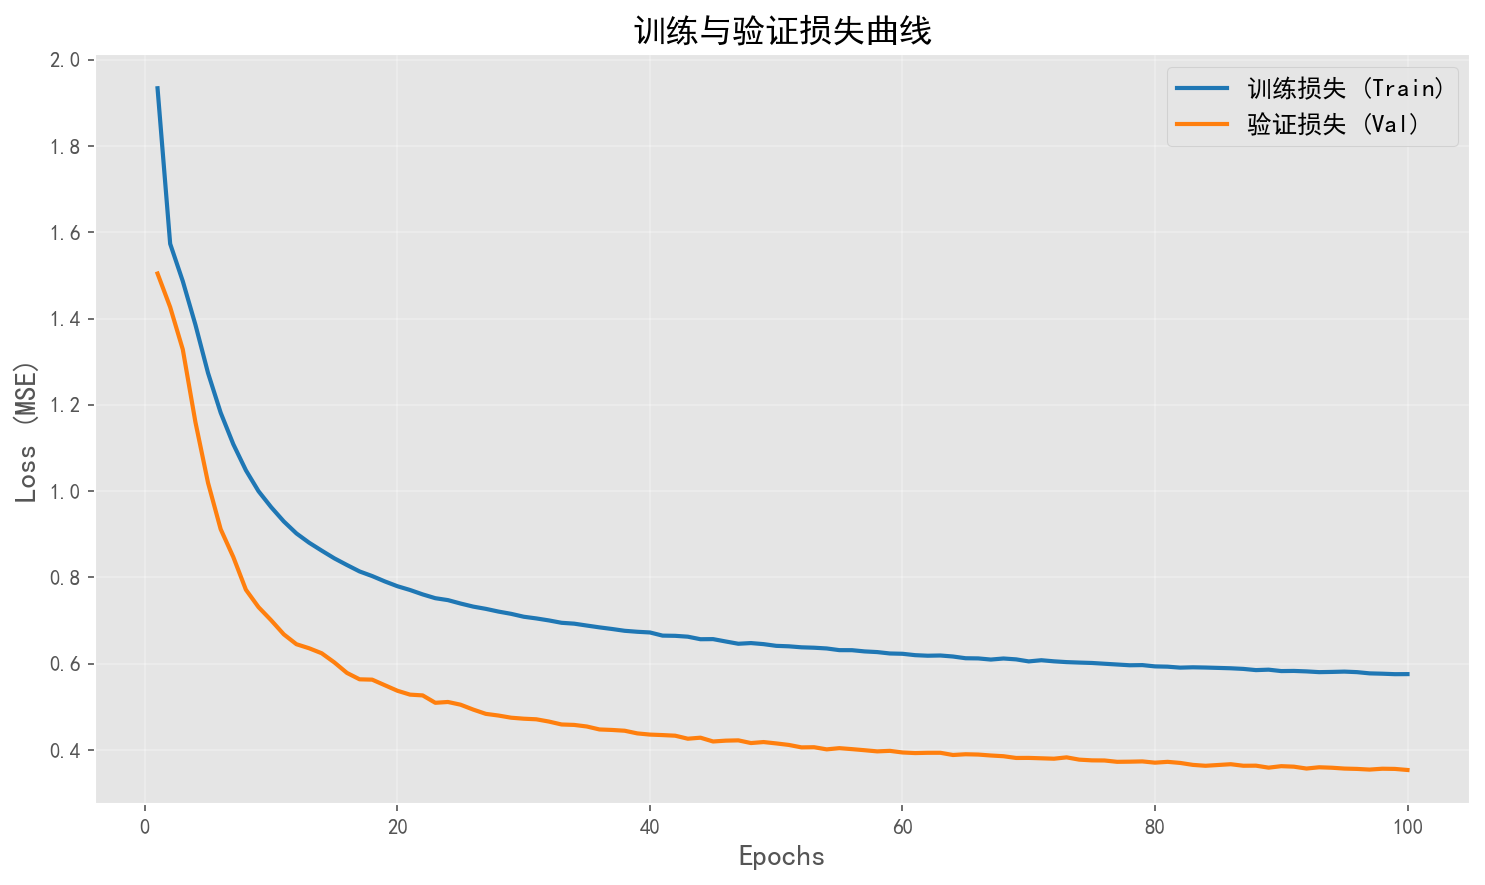

C:\Users\25711\AppData\Local\Temp\ipykernel_12376\3933433756.py:337: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\25711\AppData\Local\Temp\ipykernel_12376\3933433756.py:338: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig('prediction_results.png', dpi=150)


✓ 预测结果图已保存: prediction_results.png


d:\conda_envs\deepLearning\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


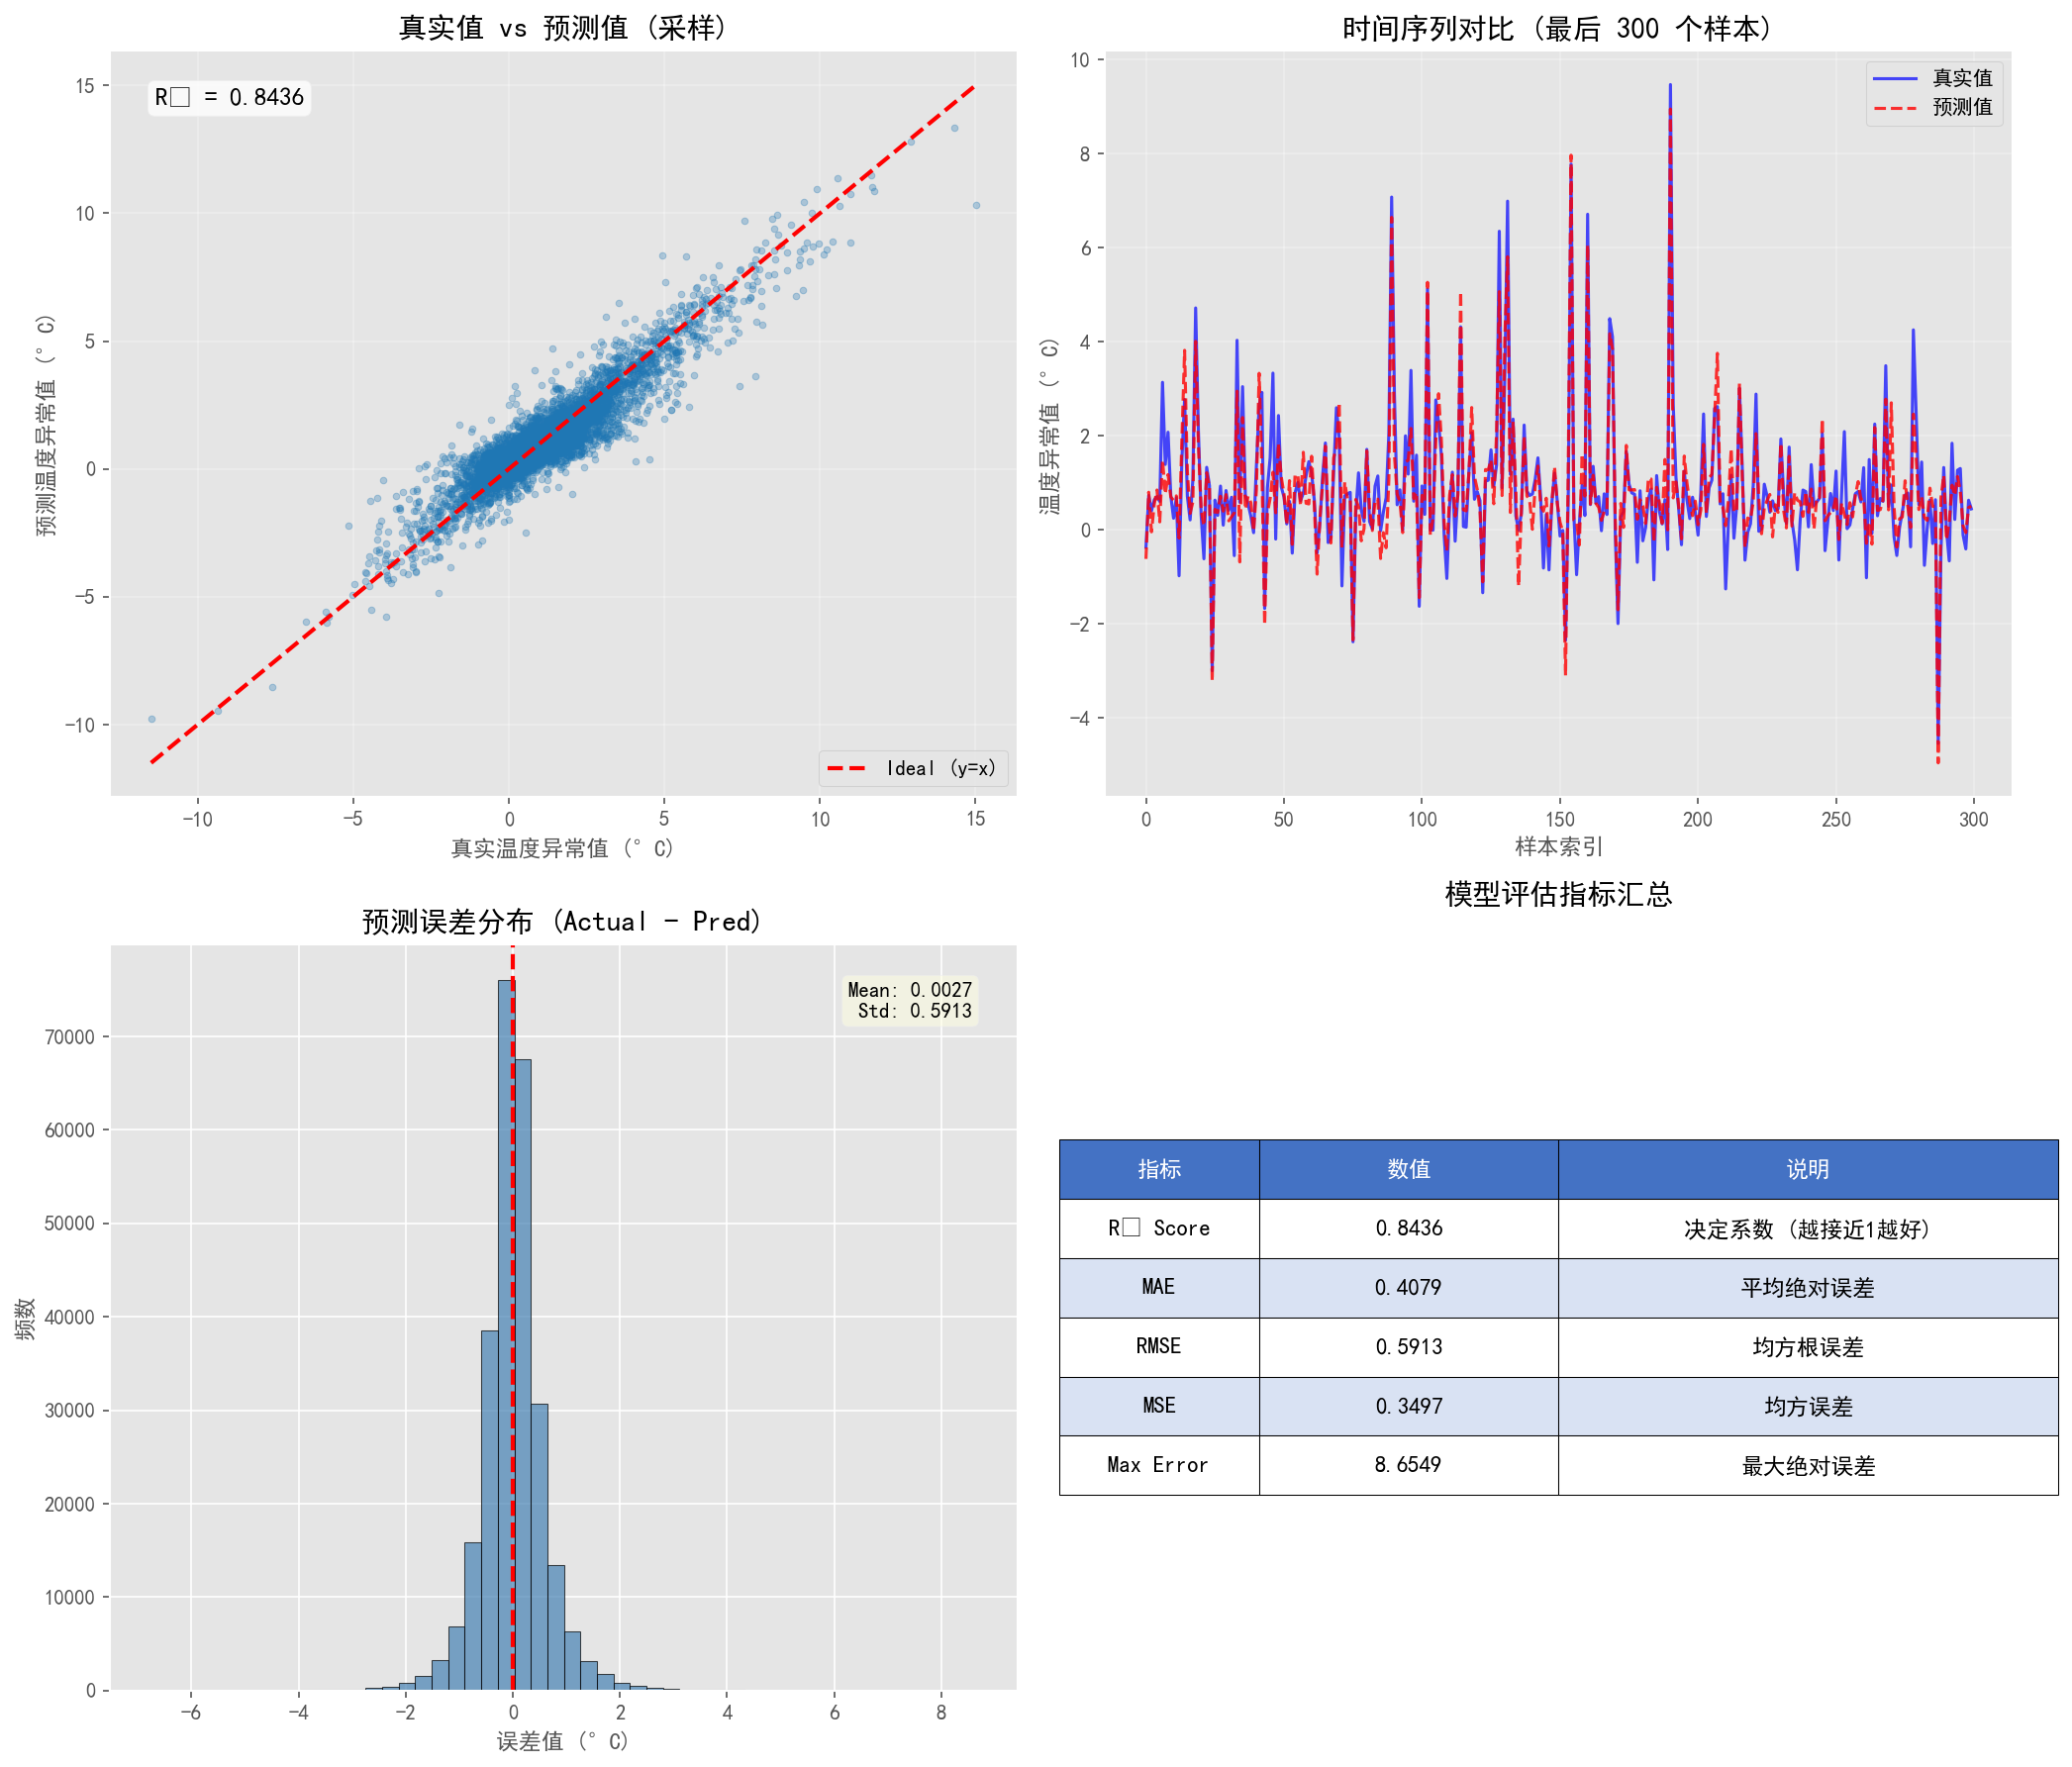


✓ 所有任务完成！


In [ ]:
# ModelTrainer.py (完整修复版)
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import numpy as np
import random
import os
import joblib
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ================= 配置与工具函数 =================

def setup_seed(seed):
    """
    设置随机种子，确保结果可复现
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

# 设置全局随机种子
setup_seed(42)

# 设置绘图风格
plt.style.use('ggplot')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Times New Roman', 'Arial'] # 适配多种环境的字体
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

# ================= 模型定义 =================

class FCNModel(nn.Module):
    """
    全连接神经网络模型 (用于回归任务)
    """
    def __init__(self, input_size, hidden_sizes=[512, 256, 128, 64], output_size=1, dropout=0.2):
        super(FCNModel, self).__init__()
        layers = []
        current_size = input_size
        for h_size in hidden_sizes:
            layers.append(nn.Linear(current_size, h_size))
            layers.append(nn.SiLU())  # SiLU (Swish) 激活函数表现通常优于 ReLU
            layers.append(nn.BatchNorm1d(h_size))
            layers.append(nn.Dropout(dropout))
            current_size = h_size

        self.feature_layers = nn.Sequential(*layers)
        # 回归任务最后一层不需要激活函数，直接映射到数值
        self.final = nn.Linear(current_size, output_size)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.final(self.feature_layers(x))

# ================= 训练器定义 =================

class ModelTrainer:
    """
    模型训练器：封装训练、评估、预测、保存逻辑
    """
    def __init__(self, input_size, hidden_sizes=[512, 256, 128, 64], output_size=1, dropout=0.2, learning_rate=0.001, device=None):
        # 自动选择设备
        if device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device('cuda' if torch.cuda.is_available() and device == 'cuda' else 'cpu')
        
        print(f'使用设备: {self.device}')
        
        # 保存参数以便稍后创建模型
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.dropout = dropout
        self.learning_rate = learning_rate
        
        self.model = None
        self.optimizer = None
        self.criterion = nn.MSELoss()  # 回归任务标准损失函数
        self.scaler = StandardScaler()
        self.history = {'train_loss': [], 'val_loss': []}
        self.best_val_loss = float('inf')

    def _create_model(self):
        """内部函数：实例化模型和优化器"""
        self.model = FCNModel(
            input_size=self.input_size,
            hidden_sizes=self.hidden_sizes,
            output_size=self.output_size,
            dropout=self.dropout
        ).to(self.device)
        
        # 只有在模型创建后，才能获取 parameters()
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=self.learning_rate, weight_decay=1e-4)

    def train_from_numpy(self, X_train, y_train, val_split=0.1, batch_size=2048, epochs=100, lr=1e-3):
        """
        主训练入口
        """
        self.learning_rate = lr
        
        # 1. 数据标准化 (Fit & Transform)
        X_scaled = self.scaler.fit_transform(X_train)
        
        # 2. 转换为张量
        X_tensor = torch.FloatTensor(X_scaled)
        y_tensor = torch.FloatTensor(y_train.reshape(-1, 1))
        
        # 3. 划分训练集和验证集
        dataset_size = len(X_tensor)
        val_size = int(dataset_size * val_split)
        train_size = dataset_size - val_size
        
        train_dataset, val_dataset = torch.utils.data.random_split(
            TensorDataset(X_tensor, y_tensor),
            [train_size, val_size]
        )
        
        # 4. 创建DataLoader
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        # 5. 如果模型未创建，则创建
        if self.model is None:
            self._create_model()
            
        return self._train_loop(train_loader, val_loader, epochs, lr)

    def _train_loop(self, train_loader, val_loader, epochs, lr):
        # 学习率调度器：当验证集loss不下降时减小学习率
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=10)
        
        patience = 30  # 早停耐心值
        early_stop_counter = 0

        for epoch in range(epochs):
            # === 训练阶段 ===
            self.model.train()
            train_losses = []
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                
                outputs = self.model(X_batch)
                loss = self.criterion(outputs, y_batch)
                
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                
                train_losses.append(loss.item())

            avg_train_loss = np.mean(train_losses)

            # === 验证阶段 ===
            self.model.eval()
            val_losses = []
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                    outputs = self.model(X_batch)
                    loss = self.criterion(outputs, y_batch)
                    val_losses.append(loss.item())

            avg_val_loss = np.mean(val_losses)
            
            # 更新学习率
            scheduler.step(avg_val_loss)
            
            # 记录历史
            self.history['train_loss'].append(avg_train_loss)
            self.history['val_loss'].append(avg_val_loss)

            # 打印日志
            if (epoch + 1) % 1 == 0:
                print(f'Epoch [{epoch + 1}/{epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}')

            # === 早停机制与模型保存 ===
            if avg_val_loss < self.best_val_loss:
                self.best_val_loss = avg_val_loss
                early_stop_counter = 0
                # 保存最佳模型
                torch.save(self.model.state_dict(), 'best_climate_model.pth')
                joblib.dump(self.scaler, 'scaler.pkl')
                print(f"  >>>此处保存最佳模型 (Val Loss: {avg_val_loss:.5f})")
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print(f"验证损失未改善，提前停止训练。停止于 Epoch {epoch + 1}")
                    break

        # 训练结束后重新加载最佳模型
        if os.path.exists('best_climate_model.pth'):
            self.model.load_state_dict(torch.load('best_climate_model.pth', map_location=self.device))
            print(f"✓ 已加载最佳模型参数，验证损失: {self.best_val_loss:.4f}")
        
        return self.history

    def predict(self, X):
        """
        预测函数
        """
        self.model.eval()
        # 注意：测试集必须使用与训练集相同的Scaler参数进行Transform，绝对不能fit
        X_scaled = self.scaler.transform(X)
        X_tensor = torch.FloatTensor(X_scaled).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(X_tensor)
            # 这是一个回归任务，不要使用Sigmoid，直接输出
            predictions = outputs.cpu().numpy() 
        return predictions

# ================= 可视化函数 =================

def plot_loss_history(history):
    """绘制损失曲线"""
    fig, ax = plt.subplots(figsize=(10, 6))
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], label='训练损失 (Train)', color='#1f77b4', lw=2)
    ax.plot(epochs, history['val_loss'], label='验证损失 (Val)', color='#ff7f0e', lw=2)
    ax.legend(fontsize=12)
    ax.set_title('训练与验证损失曲线', fontsize=16, weight='bold')
    ax.set_xlabel('Epochs', fontsize=14)
    ax.set_ylabel('Loss (MSE)', fontsize=14)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/output/loss_curve.png', dpi=300)
    print("✓ 损失曲线已保存: output/loss_curve.png")
    plt.show()

def plot_prediction_results(y_test, y_pred, metrics):
    """
    绘制预测结果详细分析图 (2x2 布局)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # --- 子图1: 散点图 (Actual vs Predicted) ---
    ax1 = axes[0, 0]
    # 随机采样最多10000个点，避免绘图过慢
    sample_size = min(10000, len(y_test))
    indices = np.random.choice(len(y_test), sample_size, replace=False)
    
    y_test_sample = y_test[indices]
    y_pred_sample = y_pred[indices].flatten()

    ax1.scatter(y_test_sample, y_pred_sample, alpha=0.3, s=10, c='#1f77b4')
    
    # 绘制 y=x 参考线
    min_val = min(y_test_sample.min(), y_pred_sample.min())
    max_val = max(y_test_sample.max(), y_pred_sample.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal (y=x)')
    
    ax1.set_title('真实值 vs 预测值 (采样)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('真实温度异常值 (°C)', fontsize=11)
    ax1.set_ylabel('预测温度异常值 (°C)', fontsize=11)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 显示 R2
    ax1.text(0.05, 0.95, f'R² = {metrics["r2"]:.4f}', transform=ax1.transAxes,
             fontsize=12, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # --- 子图2: 时间序列对比 (局部) ---
    ax2 = axes[0, 1]
    # 取最后 300 个样本展示细节
    ts_len = min(300, len(y_test))
    ax2.plot(range(ts_len), y_test[-ts_len:], 'b-', label='真实值', linewidth=1.5, alpha=0.7)
    ax2.plot(range(ts_len), y_pred[-ts_len:], 'r--', label='预测值', linewidth=1.5, alpha=0.8)
    
    ax2.set_title(f'时间序列对比 (最后 {ts_len} 个样本)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('样本索引', fontsize=11)
    ax2.set_ylabel('温度异常值 (°C)', fontsize=11)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # --- 子图3: 误差分布直方图 ---
    ax3 = axes[1, 0]
    errors = y_test - y_pred.flatten()
    ax3.hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
    
    ax3.set_title('预测误差分布 (Actual - Pred)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('误差值 (°C)', fontsize=11)
    ax3.set_ylabel('频数', fontsize=11)
    
    stats_text = f'Mean: {np.mean(errors):.4f}\nStd: {np.std(errors):.4f}'
    ax3.text(0.95, 0.95, stats_text, transform=ax3.transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

    # --- 子图4: 指标表格 ---
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    metrics_data = [
        ['R² Score', f'{metrics["r2"]:.4f}', '决定系数 (越接近1越好)'],
        ['MAE', f'{metrics["mae"]:.4f}', '平均绝对误差'],
        ['RMSE', f'{metrics["rmse"]:.4f}', '均方根误差'],
        ['MSE', f'{metrics["mse"]:.4f}', '均方误差'],
        ['Max Error', f'{metrics["max_error"]:.4f}', '最大绝对误差']
    ]
    
    # 绘制表格
    table = ax4.table(cellText=metrics_data,
                      colLabels=['指标', '数值', '说明'],
                      cellLoc='center',
                      loc='center',
                      colWidths=[0.2, 0.3, 0.5])
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.1, 2.0) # 调整表格宽高
    
    # 表格美化
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#4472C4') # 表头颜色
            cell.set_text_props(color='white', weight='bold')
        elif row > 0 and row % 2 == 0:
            cell.set_facecolor('#D9E2F3') # 偶数行颜色
            
    ax4.set_title('模型评估指标汇总', fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig('output/prediction_results.png', dpi=150)
    print("✓ 预测结果图已保存: output/prediction_results.png")
    plt.show()

# ================= 数据加载与主程序 =================

def load_climate_data(path):
    """加载并预处理数据"""
    print(f"正在读取数据文件: {path}")
    
    # 1. 尝试读取文件
    if not os.path.exists(path):
        print(f"× 文件未找到: {path}")
        print(">>> 正在生成模拟数据以供测试...")
        # 生成模拟数据用于代码测试
        dates = pd.date_range(start='1950-01-01', periods=5000, freq='M')
        df = pd.DataFrame({
            'year': dates.year,
            'month': dates.month,
            'lat': np.random.uniform(-90, 90, 5000),
            'lon': np.random.uniform(-180, 180, 5000),
            'anomaly': np.sin(np.linspace(0, 20, 5000)) + np.random.normal(0, 0.2, 5000)
        })
    else:
        df = pd.read_csv(path)
        print(f"✓ 读取成功，形状: {df.shape}")

    # 2. 特征工程
    # 将月份转换为循环特征 (sin/cos)
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
    # 年份归一化 (简单的 Min-Max)
    df['year_norm'] = (df['year'] - df['year'].min()) / (df['year'].max() - df['year'].min())
    
    # 3. 准备 X 和 y
    feature_cols = ['year_norm', 'month', 'lat', 'lon', 'sin_month', 'cos_month']
    target_col = 'anomaly'
    
    # 确保没有NaN
    df = df.dropna()
    
    X = df[feature_cols].values
    y = df[target_col].values
    
    # 4. 划分数据集 (shuffle=False 保持时间序列顺序，如果有的话)
    # 如果数据本身不是按时间严格排序的，建议这里 shuffle=True
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True
    )
    
    print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")
    return X_train, y_train, X_test, y_test

def main():
    # 数据文件路径
    data_path = 'D:\\python_demo\\coding\\deepLearning\\data\\merged_data_year_month.csv'
    
    # 1. 加载数据
    try:
        X_train, y_train, X_test, y_test = load_climate_data(data_path)
    except Exception as e:
        print(f"数据处理出错: {e}")
        return

    # 2. 初始化训练器
    print("\n>>> 初始化模型...")
    trainer = ModelTrainer(
        input_size=X_train.shape[1],  # 根据数据特征维度自动设置
        hidden_sizes=[512, 256, 128, 64],
        learning_rate=0.001,
        device=None # 自动选择
    )

    # 3. 开始训练
    print("\n>>> 开始训练...")
    history = trainer.train_from_numpy(
        X_train, y_train,
        val_split=0.1,
        batch_size=2048,
        epochs=100,
        lr=0.001
    )

    # 4. 预测与评估
    print("\n>>> 正在评估模型...")
    y_pred = trainer.predict(X_test)
    
    # 确保 y_pred 和 y_test 维度一致
    y_test = y_test.flatten()
    y_pred = y_pred.flatten()

    # 计算各项指标
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    errors = np.abs(y_test - y_pred)
    
    print("=" * 60)
    print(f"{'模型最终评估结果':^60}")
    print("=" * 60)
    print(f"  R² Score:  {r2:.4f}")
    print(f"  MAE:       {mae:.4f}")
    print(f"  RMSE:      {rmse:.4f}")
    print("=" * 60)

    # 准备指标字典用于绘图
    metrics = {
        'r2': r2, 'mae': mae, 'mse': mse, 'rmse': rmse,
        'max_error': np.max(errors)
    }

    # 5. 可视化
    print("\n>>> 生成可视化图表...")
    plot_loss_history(history)
    plot_prediction_results(y_test, y_pred, metrics)
    
    print("\n✓ 所有任务完成！")

if __name__ == "__main__":
    main()

## 手写体
### 卷积和池化后输出的特征图大小
### 1. 通用计算公式

假设输入特征图的尺寸为 $H_{in} \times W_{in}$（高度 $\times$ 宽度），池化核或卷积核（Kernel/Filter）大小为 $K$，步长（Stride）为 $S$，填充（Padding）为 $P$。  
K的取值是在不同阶段的取值是吧比如在卷积是是卷积核，池化时是池化核。

输出的高度 $H_{out}$ 和宽度 $W_{out}$ 计算公式为：

$$H_{out} = \left\lfloor \frac{H_{in} - K + 2P}{S} \right\rfloor + 1$$

$$W_{out} = \left\lfloor \frac{W_{in} - K + 2P}{S} \right\rfloor + 1$$

**符号说明：**

- $\lfloor \cdot \rfloor$ ：表示**向下取整**（Floor），即直接舍去小数部分。这意味着如果池化核滑到边缘时，剩下的像素不足以覆盖一个完整的核，这部分通常会被丢弃（除非使用了特定的 Padding 策略）。
- $K$ (Kernel Size)：池化窗口的大小（例如 $2 \times 2$ 则 $K=2$）。
- $S$ (Stride)：窗口滑动的步长。
- $P$ (Padding)：在边缘填充的像素数（池化层通常 $P=0$，但在某些特定架构中会使用）。

### 2. 逐层尺寸推导示例

假设输入图片格式为：`(Batch_Size, 1, 28, 28)`

#### **第一阶段：Conv1 + Pool**

1. **Conv1 (`kernel=3, padding=1, stride=1`)**
   - 公式：$(28 - 3 + 2 \times 1) / 1 + 1 = 28$
   - **尺寸变化：** $28 \times 28 \rightarrow 28 \times 28$ （尺寸不变）
   - **通道变化：** $1 \rightarrow 16$
   - **输出：** `(16, 28, 28)`
2. **Pool1 (`kernel=2, stride=2`)**
   - 公式：$(28 - 2) / 2 + 1 = 14$
   - **尺寸变化：** $28 \times 28 \rightarrow 14 \times 14$ （尺寸减半）
   - **输出：** `(16, 14, 14)`

------

#### **第二阶段：Conv2 + Pool**

1. **Conv2 (`kernel=3, padding=1, stride=1`)**
   - 公式：$(14 - 3 + 2 \times 1) / 1 + 1 = 14$
   - **尺寸变化：** $14 \times 14 \rightarrow 14 \times 14$ （尺寸不变）
   - **通道变化：** $16 \rightarrow 32$ （依据 `nn.Conv2d(16, 32, ...)`）
   - **输出：** `(32, 14, 14)`
2. **Pool2 (假设你在 forward 中再次使用了 `self.pool`)**
   - 公式：$(14 - 2) / 2 + 1 = 7$
   - **尺寸变化：** $14 \times 14 \rightarrow 7 \times 7$ （再次减半）
   - **输出：** `(32, 7, 7)`

------

### 2. 全连接层计算

到了全连接层，我们需要把特征图“拉平”（Flatten）。

- **最终特征图数量（通道数）：** 32 (来自 Conv2 的输出通道)
- **最终特征图高度：** 7
- **最终特征图宽度：** 7

计算全连接层输入维度：



$$输入维度 = \text{通道数} \times \text{高度} \times \text{宽度} = 32 \times 7 \times 7 = 1568$$

In [2]:
from matplotlib.pyplot import cla
import torch.nn as nn
import torch.nn.functional as F # 导入函数式接口
import torch

#创建模型cnn假设（28， 28）输入图像
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        #卷积层：提取特征
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1) #（16,28, 28 ） 输入通道1，输出通道16，卷积核3x3，填充1 , 卷积层m, 步长默认1
        #池化层：降维，减少计算量
        self.pool = nn.MaxPool2d(2, 2) # (16, 14, 14) 最大池化，窗口2x2，步长2, 池化层
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # (32, 14, 14) 输入通道16，输出通道32，卷积核3x3，填充1, 卷积层
        self.pool = nn.MaxPool2d(2, 2) # (32, 7, 7) 最大池化，窗口2x2，步长2, 池化层
        #全连接层：输入输出
        #维度计算依据：经过两次池化，尺寸减半两次，假设输入图像尺寸为20x20，则经过两次池化后变为5x5
        self.liner1 = nn.Linear(32*7*7, 256) # 全连接层，输入尺寸32*7*7，通过前面计算，输出256
        self.liner2 = nn.Linear(256, 10) # 全连接层，输入256，输出10， 输出是自定义的
    def forward(self, x):
        #第一层卷积 -> ReLU激活函数,提取基本特征
        x = F.relu(self.conv1(x))
        # 池化操作,降低特征图尺寸
        x = self.pool(x)
        # 第二层卷积->ReLU激活函数,提取更复杂的特征
        x = F.relu(self.conv2(x))
        # 第二次池化,进一步缩小特征图尺寸
        x = self.pool(x)
        # print(x.size())
        # 将四维特征张量(batch_size,channels,height,width)展平为二维张量(batch_size,channels*height*width)
        #-1表示自定计算维度大小,保证总元素个数不变,适配批量输入
        x=x.view(x.size(0),-1) #或者 等价于x=x.view(-1,32*5*5)
        # 全连接层1 -> ReLU激活函数,学习非线性组合特征
        #CroessEntropyLoss()函数中已经包含了Softmax操作,所以这里不需要再加Softmax
        x = F.relu(self.liner1(x)) 
        # 全连接层2,输出最终分类结果
        x = self.liner2(x)
        return x
#config.py
# 配置文件，定义超参数等
class config:
    # 数据路径
    data_path = 'D:\\python_demo\\coding\\deepLearning'
    # 模型保存路径
    epochs = 50
    plot_num = 10
    classes = 10
    model_save_path = './MNISTmodel.pth'
    # 训练参数
    batch_size = 32
    learning_rate = 0.001

In [ ]:

#train.py

def fit(epoch, model, trainloader, testloader, loss_fn, optim, device, bst_loss):
    """
    执行单次训练和验证过程
    参数：
    epoch: 当前训练轮数
    model: 待训练的模型
    trainloader: 训练数据加载器
    testloader: 测试数据加载器
    loss_fn: 损失函数
    optim: 优化器
    device: 计算设备（CPU或GPU）
    bst_loss: 当前最佳验证损失
    """
    #初始化训练集的正确预测数，总样本数，累计损失
    correct = 0
    total = 0
    running_loss = 0
    model.train() # 建议加上显式的训练模式开启
    #遍历训练集数据加载器，逐批次训练
    for x, y in trainloader:
        #将数据和标签移动到指定设备
        x, y = x.to(device, dtype=torch.float), y.to(device, dtype=torch.long)
        #前向传播，计算模型输出
        outputs = model(x)
        #计算损失
        loss = loss_fn(outputs, y)
        #梯度清零
        optim.zero_grad()
        #反向传播，计算梯度
        loss.backward()
        #更新模型参数
        optim.step()
        #评估当前批次的预测准确性
        with torch.no_grad():
            #对预测输出按维度1取最大值， 得到预测类别
            y_pred = torch.argmax(outputs, dim=1)
            #累计正确预测数和总样本数
            correct += (y_pred == y).sum().item()
            total += y.size(0)
            #累计损失
            running_loss += loss.item()
    
    #计算当前轮次训练集的准确率
    epoch_acc = correct / total
    #计算当前伦次训练集的平均损失
    epoch_loss = running_loss / len(trainloader)
    #初始化测试集的正确预测数，总样本数，累计损失
    test_correct = 0
    test_total = 0
    test_running_loss = 0
    #遍历测试集数据加载器，逐批次验证
    # 遍历测试集数据加载器，逐批次验证
    model.eval() 
    with torch.no_grad():
        for x, y in testloader:
            # 1. 确保数据类型与训练阶段一致
            x = x.to(device, dtype=torch.float)
            y = y.to(device, dtype=torch.long)
            
            # 2. 前向传播
            outputs = model(x)
            loss = loss_fn(outputs, y)
            
            # 3. 统计
            y_pred = torch.argmax(outputs, dim=1)
            test_correct += (y_pred == y).sum().item()
            test_total += y.size(0)
            
            # 建议：乘以样本数以获得更精确的平均值
            test_running_loss += loss.item() * x.size(0)

    # 4. 计算最终平均损失
    test_epoch_loss = test_running_loss / len(testloader.dataset) # 注意这里除以总样本数
    test_epoch_acc = test_correct / test_total
    #打印当前轮次的训练和测试结果
    print(f"Epoch [{epoch+1}], Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Test Loss: {test_epoch_loss:.4f}, Test Acc: {test_epoch_acc:.4f}")
    #如果当前测试集损失优于最佳损失，则保存模型
    if test_epoch_loss < bst_loss:
        bst_loss = test_epoch_loss
        save_path = getattr(config, 'save_model_path', getattr(config, 'model_save_path', getattr(config, 'save_path', './model.pth')))
        torch.save(model.state_dict(), save_path)
        print(f"  >>> 保存最佳模型，测试集损失: {bst_loss:.4f}")
    return epoch_loss, epoch_acc, test_epoch_loss, test_epoch_acc, bst_loss


使用设备: cuda
单个批次输入样本形状: torch.Size([32, 1, 28, 28]), 标签形状: torch.Size([32])
Epoch [1], Train Loss: 0.1232, Train Acc: 0.9617, Test Loss: 0.0584, Test Acc: 0.9817
  >>> 保存最佳模型，测试集损失: 0.0584
Epoch [2], Train Loss: 0.0436, Train Acc: 0.9862, Test Loss: 0.0466, Test Acc: 0.9846
  >>> 保存最佳模型，测试集损失: 0.0466
Epoch [3], Train Loss: 0.0299, Train Acc: 0.9905, Test Loss: 0.0376, Test Acc: 0.9893
  >>> 保存最佳模型，测试集损失: 0.0376
Epoch [4], Train Loss: 0.0206, Train Acc: 0.9932, Test Loss: 0.0302, Test Acc: 0.9901
  >>> 保存最佳模型，测试集损失: 0.0302
Epoch [5], Train Loss: 0.0165, Train Acc: 0.9945, Test Loss: 0.0296, Test Acc: 0.9913
  >>> 保存最佳模型，测试集损失: 0.0296
Epoch [6], Train Loss: 0.0125, Train Acc: 0.9958, Test Loss: 0.0335, Test Acc: 0.9904
Epoch [7], Train Loss: 0.0111, Train Acc: 0.9961, Test Loss: 0.0366, Test Acc: 0.9901
Epoch [8], Train Loss: 0.0086, Train Acc: 0.9970, Test Loss: 0.0369, Test Acc: 0.9893
Epoch [9], Train Loss: 0.0071, Train Acc: 0.9979, Test Loss: 0.0369, Test Acc: 0.9915
Epoch [10], Trai

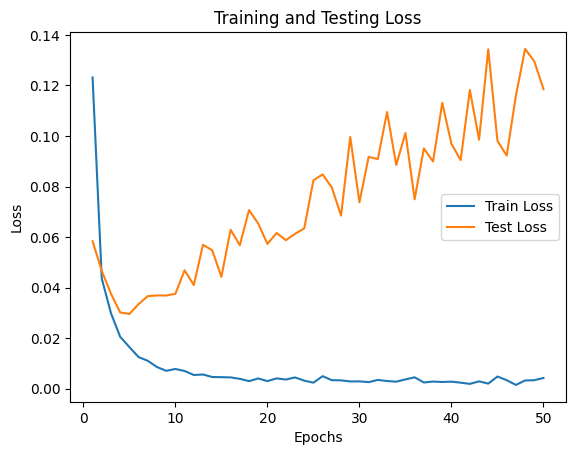

In [ ]:
#main.py
import torchvision.transforms as transforms
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#创建dataloader, 定义损失优化器等， 使用模板fiy函数进行训练
torch.cuda.empty_cache() #清空缓存
#1, 加载参数
config = config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")
#定义数据处理
transformation = transforms.Compose([
    transforms.ToTensor(), #将图像转换为张量
    transforms.Normalize((0.1307,), (0.3081,)), #标准化，均值和标准差
])
# 创建数据集dataloader
#trian=True表示加载训练集， false表示加载测试集， transform表示数据预处理， shuffle表示是否打乱数据
train_ds = datasets.MNIST(config.data_path, train=True, download=True, transform=transformation)
test_ds = datasets.MNIST(config.data_path, train=False, download=True, transform=transformation)
train_dl = DataLoader(train_ds, batch_size=config.batch_size, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=config.batch_size, shuffle=False)

#观察每个输入的样本形状
imgs, labels = next(iter(train_dl))
print(f"单个批次输入样本形状: {imgs.shape}, 标签形状: {labels.shape}")

#导入模型
model = Model().to(device) #实例化模型并移动到指定设备
loss_fn = torch.nn.CrossEntropyLoss()
#创建优化器
optim = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
#初始化所有文件
train_loss = []
train_acc = []
test_loss = []
test_acc = []
bst_loss = np.inf
#创建loss.csv和acc.csv文件
df1 = pd.DataFrame(columns=["train_loss", "test_loss"])
df2 = pd.DataFrame(columns=["train_acc", "test_acc"])
df1.to_csv("./loss.csv", index=False)
df2.to_csv("./acc.csv", index=False)
#开始训练并存储数据到csv
for epoch in range(config.epochs):
    epoch_loss, epoch_acc, test_epoch_loss, test_epoch_acc, bst_loss = fit(epoch, model, train_dl, test_dl, loss_fn, optim, device, bst_loss)
    list1 = [epoch_loss, test_epoch_loss]
    data1 = pd.DataFrame([list1], columns=["train_loss", "test_loss"])
    data1.to_csv("./loss.csv", mode="a", header=False, index=False)
    list2 = [epoch_acc, test_epoch_acc]
    data2 = pd.DataFrame([list2], columns=["train_acc", "test_acc"])
    data2.to_csv("./acc.csv", mode="a", header=False, index=False)
    train_loss.append(epoch_loss)
    test_loss.append(test_epoch_loss)
    train_acc.append(epoch_acc)
    test_acc.append(test_epoch_acc)
#训练结果可视化,将两个视图放到一个图像中
fig, axes = plt.subplots(2, 1, figsize=(10, 12))
#损失曲线
ax1 = axes[0]
ax1.plot(range(1, config.epochs+1), train_loss, label="Train Loss")
ax1.plot(range(1, config.epochs+1), test_loss, label="Test Loss")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.set_title("Training and Testing Loss")
ax1.legend()

#准确率曲线
ax2 = axes[1]
ax2.plot(range(1, config.epochs+1), train_acc, label="Train Acc")
ax2.plot(range(1, config.epochs+1), test_acc, label="Test Acc")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training and Testing Accuracy")
ax2.legend()

# plt.savefig("./loss_curve.png")
plt.show()



模型预测结果:[3 3 6 0 2 2 5 1 8 4]
实际标签:[3 3 6 0 2 2 5 1 8 4]


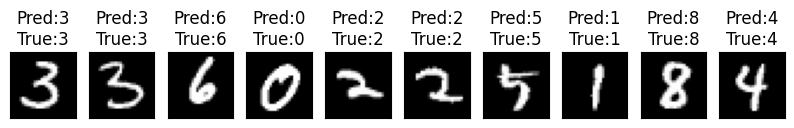

In [4]:
# ...existing code...
# test_path.py（修复版）
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 安全获取配置实例：若 notebook 中 config 是类则实例化；若已是实例则直接使用
try:
    if isinstance(config, type):
        cfg = config()
    else:
        cfg = config
except NameError:
    raise RuntimeError("未找到名为 'config' 的类或实例，请先定义 class config 或在本单元前导入。")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transformation = transforms.Compose([
    transforms.ToTensor(),
])

test_ds = datasets.MNIST(cfg.data_path, train=False, download=True, transform=transformation)
test_dl = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=True)

# 载入模型参数并评估
model = Model().to(device)
model.load_state_dict(torch.load(cfg.model_save_path, map_location=device))
model.eval()

imgs, labels = next(iter(test_dl))

def imshow(img):
    npimg = img.numpy()
    npimg = np.squeeze(npimg)
    plt.imshow(npimg, cmap='gray')

plt.figure(figsize=(cfg.plot_num, 2))
y_pred = model(imgs[:cfg.plot_num].to(device))
print("模型预测结果:{}".format(torch.argmax(y_pred, dim=1).cpu().numpy()))
print("实际标签:{}".format(labels[:cfg.plot_num].numpy()))

for i, img in enumerate(imgs[:cfg.plot_num]):
    plt.subplot(1, cfg.plot_num, i+1)
    plt.title(f"Pred:{torch.argmax(y_pred[i]).item()}\nTrue:{labels[i].item()}")
    plt.xticks([])
    plt.yticks([])
    imshow(img)
plt.show()
# ...existing code...

## 猫狗识别案例
### 卷积神经网络参数设计
核心逻辑是：**空间维度（宽和高）逐渐缩小，通道维度（特征深度）逐渐增加。**

------

#### 深度和宽度
##### 1. “深”指的是：层数的堆叠（Depth）

当你把很多个卷积层（Conv2d）一个接一个地串联起来时，网络就变“深”了。

- **浅层（Shallow Layers）**：靠近输入图像的那几层。它们能看到具体的像素，提取的是**局部特征**（如：线条、边缘、颜色块）。
- **深层（Deep Layers）**：靠近输出（分类结果）的那几层。经过多次卷积和下采样，它们提取的是**全局语义特征**（如：眼睛的形状、轮子、整只狗的轮廓）。

------

#### 2. 卷积核的个数（Channels）被称为“宽度”

你在 `nn.Conv2d(in_channels, out_channels, ...)` 中设置的 `out_channels`，其实是卷积核的**个数**。

- 如果你设置 `out_channels=64`，意味着这一层有 64 个不同的滤镜，每个滤镜负责寻找一种特定的特征。
- 这在术语中通常被称为网络的**宽度（Width）**，而不是深度。

------

#### 总结
增加卷积层数 = 网络变深（学习更复杂的逻辑）。

增加卷积核个数 = 网络变宽（同一层学习更多种类的特征）。

------

### 常见设计原则
#### 1. 通道数 (Channels)：由浅入深，倍数增长

通道数代表了模型提取特征的“宽度”。

- **浅层**：图像刚输入时，信息非常直观（颜色、边缘）。此时通道数不需要太多，通常从 **32** 或 **64** 开始。
- **深层**：随着空间尺寸缩小，每一层需要捕捉更高级、更抽象的语义信息（如“这是一只猫的耳朵”）。为了弥补空间信息的丢失，通常会将通道数翻倍。
- **经典模式**：$64 \rightarrow 128 \rightarrow 256 \rightarrow 512$。

------

#### 2. 步长 (Stride) 与 填充 (Padding)：控制尺寸

这两者通常配合使用，目的是在提取特征的同时，有节奏地压缩数据。

- **保持尺寸 (Same Convolution)**：在大部分卷积层中，我们希望特征图尺寸不变。
  - **策略**：`stride=1`, `padding=(kernel_size - 1) // 2`。比如 $3 \times 3$ 核配 `padding=1`。
- **缩小尺寸 (Downsampling)**：每经过一个阶段，需要将宽高减半。
  - **策略**：使用 `stride=2` 的卷积层，或者在卷积后加一个 `nn.MaxPool2d(2, 2)`。
  - **位置**：通常在通道数翻倍的那一层同时进行下采样。

------

#### 3. 卷积核大小 (Kernel Size)：由大到小或固定小核

- **第一层 (Stem)**：为了获得较大的初始感受野，有时会用 $7 \times 7$ 或 $5 \times 5$ 的大核（配合 `stride=2`），快速降低原始高清图像的分辨率。
- **中间层与深层**：现代网络（如 ResNet）几乎全采用 **$3 \times 3$** 卷积核。
  - **原因**：两个 $3 \times 3$ 堆叠的感受野等同于一个 $5 \times 5$，但参数更少，且多了两次非线性激活（ReLU），表达能力更强。
- **$1 \times 1$ 卷积**：常用于深层网络中，在不改变宽高的情况下调整通道数（升维或降维），减少计算量。

### 卷积核参数
**卷积层参数量**（Parameter Count）是指模型中需要通过训练来学习的变量总数，主要由**权重（Weights）**和**偏置（Bias）**两部分组成。

简单来说，参数量决定了模型的“脑容量”和“复杂度”。

### 1. 计算公式

对于一个 `nn.Conv2d` 层，其参数量的计算公式如下：

$$\text{Total Params} = (\underbrace{K_h \times K_w \times C_{in}}_{\text{一个卷积核的权重}} + \underbrace{1}_{\text{偏置}}) \times \underbrace{C_{out}}_{\text{卷积核数量}}$$

- $K_h, K_w$：卷积核的高度和宽度（kernel_size）。
- $C_{in}$：输入通道数（in_channels）。
- $C_{out}$：输出通道数（out_channels）。
- **偏置 (Bias)**：默认情况下 `bias=True`，每个输出通道有一个偏置值。如果设置 `bias=False`，则公式中去掉那个 $+1$。

> **注意**：输入图片的长宽尺寸（$H \times W$）**不参与**参数量的计算。无论你输入的是 $32 \times 32$ 还是 $1024 \times 1024$ 的图片，该层的参数量是固定的。

------

### 2. 你的案例计算

让我们计算你提供的这层代码的参数量：

nn.Conv2d(192, 192, kernel_size=3, stride=1, padding=1)

- $C_{in} = 192$
- $C_{out} = 192$
- $K = 3$ ($3 \times 3$)
- Bias = True (默认)

**计算步骤：**

1. **单个卷积核的权重**：$3 \times 3 \times 192 = 1,728$
2. **加上偏置**：$1,728 + 1 = 1,729$
3. **乘以输出通道数**：$1,729 \times 192 = 331,968$

**结果：** 这一层共有 **331,968** 个参数（约 0.33 M）。

------

### 3. 参数量有什么用？

参数量是一个非常关键的指标，它主要影响以下三个方面：

#### A. 模型的“智商”与拟合能力（Capacity）

- **参数实际上是什么？** 每一个参数（权重）就像是神经网络的一个“微调旋钮”。训练过程就是自动调节这 33 万个旋钮，让网络学会识别特征（如边缘、纹理、形状）。
- **作用：** 参数越多，模型能记忆和表达的信息就越丰富，能够处理更复杂的任务（比如区分 1000 种不同的物体）。

#### B. 硬件资源需求（Memory & Storage）

- **模型大小：** 参数量直接决定了模型文件（`.pth` 或 `.onnx`）的大小。
  - 通常参数是 `float32` 类型，每个参数占 4 Bytes。
  - 你的这一层占用显存/硬盘约为：$331,968 \times 4 \text{ Bytes} \approx 1.27 \text{ MB}$。
- **显存占用：** 在训练时，优化器（如 Adam）还需要存储梯度和动量信息，实际占用的显存通常是参数本身大小的 3-4 倍。

#### C. 过拟合风险（Overfitting）

- **双刃剑：** 虽然参数多能变“聪明”，但如果数据量不够大（比如只有几百张图），巨大的参数量会导致模型直接“死记硬背”训练数据，而在测试集上表现很差。这就是**过拟合**。

In [10]:
#AlexNet.py
import torch
import torch.nn as nn

#定义继承自nn.Module的神经网络模型类的AlexNet类，用于构建AlexNet神经网络
class AlexNet(nn.Module):
    #初始化方法
    #input_size: 输入图像的通道数，num_classes: 分类类别数
    def __init__(self, input_shape=(3, 224, 224), output_size=2):
        #调用父类的初始化方法
        super(AlexNet, self).__init__()

        #定义提取部分，使用squential容器按顺序堆叠各层
        self.features = nn.Sequential( #该容器在实例化时按顺序添加各层
            #第一层卷积模型，包含卷积层，Relu激活函数，池化层
            #输入通道数input_shape[0]，输出通道数48，卷积核大小11x11，步长4，padding 0
            nn.Conv2d(input_shape[0], 48, kernel_size=11, stride=4, padding=0), #卷积层
            nn.BatchNorm2d(48), #批归一化层, 48个通道且必须于卷积层输出通道数一致
            #inplace=True表示原地操作，直接修改张量数据，不额外创建新张量，节省内存
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2), #最大池化层，池化窗口3x3，步长2

            #第二层卷积模型
            nn.Conv2d(48, 128, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(128), #num_features必须与卷积层输出通道数一致
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            #第三层卷积模型
            #通道数越多，提取的特征越复杂
            #浅层少通道，深层多通道
            nn.Conv2d(128, 192, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            #第四层卷积模型
            nn.Conv2d(192, 192, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            #第五层卷积模型
            nn.Conv2d(192, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        #计算全连接层的输入特征数量，即经过所有的卷积核池化层后的特征图大小
        self.feature_size = self._get_feature_size(input_shape)

        #定义分类器部分,保罗两个全连接层和一个输出层
        self.classifier = nn.Sequential(
            #第一个全连接层
            nn.Flatten(), #将多维特征图展平成一维向量
            nn.Linear(self.feature_size, 1024), #全连接层，输入特征数量feature_size，输出1024
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5), #Dropout层，防止过拟

            #定义第二个全连接层
            nn.Linear(1024, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            #输出层
            nn.Linear(1024, output_size) #全连接层，输入1024，输出类别数output
        )
        #定义softmax层，用于多分类任务的概率输出
        self.softmax = nn.Softmax(dim=1) #dim=1表示按行进行softmax计算

    #内部方法，用于计算全连接层的输入特征数
    def _get_feature_size(self, input_shape):
        #创建一个与输入形状相同的虚拟张量
        with torch.no_grad(): #不计算梯度，节省内存
            x = torch.zeros(1, *input_shape) #创建一个全零张量，batch_size=1
            x = self.features(x) #通过特征提取部分前向传播
            feature_size = x.numel()//x.size(0) #计算输出张量的总元素数量，即特征数,x.size(0)是batch_size
        return feature_size
    
    #前向传播方法
    def forward(self, x):
        x = self.features(x) #通过特征提取部分
        x = self.classifier(x) #通过分类器部分
        x = self.softmax(x) #通过softmax层，得到概率分布
        return x

# if __name__ == "__main__":
#测试AlexNet模型
model = AlexNet()
print(model)

#创建一个随机输入张量，模拟一张3通道224x224的图像
input_tensor = torch.randn(1, 3, 224, 224)
output = model(input_tensor)
print("输出形状:", output.shape) #应为(1, 2)对应2个类别



            

            

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 48, kernel_size=(11, 11), stride=(4, 4))
    (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(48, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(192, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Se

In [11]:
#dataset_process.py
# 数据预处理与模型训练模块
import os

#os.listdir函数列出指定路径下的所有文件名，并将结果赋值给photos变量
photos = os.listdir('D:\\Users\\25711\\Downloads\\AlexNet猫狗识别数据集data\\data\\image\\train')

with open('photo_list.txt', 'w') as f:
    for photo in photos:
        name = photo.split('.')[0]  # 获取文件名（不含扩展名）
        if name == "cat":
            f.write(photo + ' 0\n')  # 猫类标签为0
        elif name == "dog":
            f.write(photo + ' 1\n')  # 狗类标签为1
# 关闭文件，注意：由于使用了with语句，文件会自动关闭，无需手动调用f.close()
f.close()

In [12]:
import matplotlib.image as mpimg
import numpy as np
import cv2

import torch
from torchvision import transforms
from PIL import Image

def load_image(path):
    img = mpimg.imread(path)
    short_edge = min(img.shape[:2])
    yy = int((img.shape[0] - short_edge) / 2)
    # 计算图像在x轴方向上需要裁剪掉的左侧和右侧像素数量,以获得中心正方形
    xx = int((img.shape[1] - short_edge) / 2)
    # 根据计算出的位置参数裁剪图像,得到中心正方形区域
    crop_img = img[yy: yy + short_edge, xx: xx + short_edge]
    # 返回裁剪后的图像
    return crop_img

def resize_image(image, size):
    """调整图片大小"""
    images = []
    # 检查输入的图像是否是三维数组(即单张图像),如果是,则添加一个维度以模拟批次(batch)
    if len(image.shape) == 3:
        image = np.expand_dims(image, axis=0)

    for i in image:
        if isinstance(i,np.ndarray):
            i = Image.fromarray((i * 255).astype(np.uint8))
        transform = transforms.Compose([
            transforms.Resize(size),
            transforms.ToTensor()
        ])

        i = transform(i)
        images.append(i)

    #使用torch.stack将所有图像堆叠成一个张量，表示整个批次

    images = torch.stack(images)
    return images

def print_answer(argmax):
    with open('./data/model/index_word.txt','r',encoding = 'utf-8') as f:
        synest = [l.split(';')[1][:-1] for l in f.readlines()]
    if torch.is_tensor(argmax):
        argmax = argmax.item()
    #打印对应于最大值索引的类别名称
    print(synest[argmax])

### 训练图片的mean和std
⚠️⚠️⚠️计算属于自己数据集的均值（Mean）和标准差（Std）是模型训练中非常关键的一步，尤其是当你的数据与常见的自然图像（如 ImageNet）差异很大时（例如医疗影像、卫星遥感图或工业检测图）。
**计算的基本思路是**：遍历训练集中的所有图片，按通道（R, G, B）分别计算所有像素点的平均值和标准差。

均值 (Mean):
$$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$$
标准差 (Standard Deviation):
$$\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2}$$
未知数说明：
- $N$：所有图片的总像素数（图片数量 $\times$ 宽度 $\times$ 高度）。
- $x_i$：第 $i$ 个像素的值（对于 RGB 图像，有三个通道，需分别计算）。
- $\mu$：均值，表示所有像素值的平均水平。
- $\sigma$：标准差，表示像素值的分布范围（离散程度）。
- **注意**：计算均值和标准差时，通常会先将像素值归一化到 $[0, 1]$ 范围（即除以 255），以确保数值稳定性。
#### 示例
##### 1. 准备数据 (归一化后)

我们将像素值缩放到 $[0, 1]$ 之间：

- **图片 A**: $\begin{bmatrix} 0.1 & 0.2 \\ 0.3 & 0.4 \end{bmatrix}$
- **图片 B**: $\begin{bmatrix} 0.5 & 0.6 \\ 0.7 & 0.8 \end{bmatrix}$

这里总像素个数 **$N = 2 (\text{张}) \times 2 (\text{宽}) \times 2 (\text{高}) = 8$**。

------

##### 2. 计算均值 ($\mu$)

**公式**：$\mu = \frac{1}{N} \sum x_i$

1. 求所有像素之和：

   $\text{Sum} = (0.1 + 0.2 + 0.3 + 0.4) + (0.5 + 0.6 + 0.7 + 0.8) = 1.0 + 2.6 = 3.6$

2. 除以 $N$：

   $\mu = 3.6 / 8 = \mathbf{0.45}$

------

##### 3. 计算标准差 ($\sigma$)

**公式**：$\sigma = \sqrt{\frac{1}{N} \sum (x_i - \mu)^2}$

我们需要算出每个像素与均值 $0.45$ 的“距离平方”：

| **像素 xi** | **离差 (xi−μ)**      | **离差平方 (xi−μ)2** |
| ----------- | -------------------- | -------------------- |
| 0.1         | $0.1 - 0.45 = -0.35$ | $0.1225$             |
| 0.2         | $0.2 - 0.45 = -0.25$ | $0.0625$             |
| 0.3         | $0.3 - 0.45 = -0.15$ | $0.0225$             |
| 0.4         | $0.4 - 0.45 = -0.05$ | $0.0025$             |
| 0.5         | $0.5 - 0.45 = +0.05$ | $0.0025$             |
| 0.6         | $0.6 - 0.45 = +0.15$ | $0.0225$             |
| 0.7         | $0.7 - 0.45 = +0.25$ | $0.0625$             |
| 0.8         | $0.8 - 0.45 = +0.35$ | $0.1225$             |

1. 求离差平方和：

   $\sum (x_i - \mu)^2 = 0.1225 + 0.0625 + 0.0225 + 0.0025 + 0.0025 + 0.0225 + 0.0625 + 0.1225 = \mathbf{0.42}$

2. 计算方差 ($\sigma^2$)：

   $\sigma^2 = 0.42 / 8 = 0.0525$

3. 计算标准差 ($\sigma$)：

   $\sigma = \sqrt{0.0525} \approx \mathbf{0.229}$


#### 关键注意事项
- 只计算训练集：均值和标准差应该只从**训练集(Train Set)**中计算得出。在验证集和测试集上，直接套用训练集的这些数值。这是为了模拟真实场景（即模型在未知数据上的表现）。
- 计算前先缩放：计算均值时的图像尺寸（Resize）最好与你训练模型时使用的尺寸一致。
- 黑白图片：如果你的输入是灰度图（单通道），均值和标准差将只有一个数值，而不是三个。

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import numpy as np
import cv2
import os
from torchvision import transforms
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts # 学习率调度器
import matplotlib. pyplot as plt


# 定义训练数据增强策略,包括随机裁剪、水平翻转、旋转以及颜色抖动等操作,并进行归一化处理
train_transform = transforms. Compose([
    transforms.ToPILImage(), #将Numpy数组张量转换为PIL图像
    transforms.RandomResizedCrop(224),#随机大小裁剪并调整到224x224大小
    transforms.RandomHorizontalFlip(p=0.5),#随机水平翻转
    transforms.RandomRotation(15),#随机旋转最多15度
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),#随机改变亮度、对比度和饱和度
    #转换为PyTorch张量并归一化到[0,1]
    transforms.ToTensor(),
    #标准化
    # 1. 加速收敛：使输入分布更稳定
    # 2. 数值稳定性：防止梯度爆炸/消失
    # 3. 兼容预训练模型：使用与训练时相同的统计量
    transforms.Normalize(mean = [0.485,0.456,0.406],std = [0.229,0.224,0.225])
])
# 定义验证集转换,只包含基本的尺寸调整和中心裁剪,并进行归一化处理
val_transform = transforms. Compose([
    transforms.ToPILImage(),#将Numpy数组或张量转换为PIL图像
    transforms.Resize(256),#将最短边调整到256像素
    transforms.CenterCrop(224),#中心裁剪到224×224大小
    transforms.ToTensor(),#转换PyTorch张量并归一化到[0,1]
    transforms. Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

class CustomDataset(Dataset):
    def __init__(self,lines,transform = None,is_train = True):
        self.lines = lines
        self.transform = transform
        self.is_train = is_train

    def __len__(self):
        return len(self.lines)

    def __getitem__(self,idx):
        try:
            line_content = self.lines[idx].strip()
            name = self.lines[idx].strip().split(';')[0]
            img = cv2.imread(os.path.join('./data/image/train',name))
            img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
            label = int(self.lines[idx].strip().split(';')[1])

            if self.transform:
                img = self.transform(img)

            return img,label
        except Exception as e:
            print(f"Error loading image {name}:{str(e)}")  # 如果读取过程中出现问题,打印错误信息
            return self.__getitem__(0)  # 返回第一个样本作为替代


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs, log_dir,patience=7):
        history = {
            'train_loss':[],'train_acc':[],
            'val_loss':[],'val_acc':[],
            'lr':[]
        }
        best_val_acc = 0
        counter = 0

        for epoch in range(num_epochs):  # 开始训练循环,迭代num_epochs次
            # 训练阶段
            model.train()  # 设置模型为训练模式
            train_loss = 0  # 初始化训练损失为9
            train_correct = 0  # 初始化训练正确预测数为9
            train_total = 0  # 初始化训练样本总数为日

            for batch_idx, (images, labels) in enumerate(train_loader):  # 遍历训练数据加载器
                images, labels = images.to(device), labels.to(device)  # 将图像和标签移动到指定设备(CPU或GPU)

                optimizer.zero_grad()  # 清空之前计算的梯度
                outputs = model(images)  # 前向传播,得到模型的输出
                loss = criterion(outputs, labels)
                loss.backward()  # 反向传播,计算梯度

                # 梯度裁剪,防止梯度爆炸
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                optimizer.step()  # 更新模型参数

                # 累加损失
                # 获取预测结果
                train_loss += loss.item()
                _, predicted = outputs.max(1)
                train_total += labels.size(0)  # 累加样本总数
                train_correct += predicted.eq(labels).sum().item()

            train_loss = train_loss / len(train_loader)  # 计算平均训练损失
            train_acc = 100. * train_correct / train_total  # 计算训练准确率

            # 验证阶段
            model.eval()  # 设置模型为评估模式
            val_loss = 0  # 初始化验证损失为e
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for images,labels in val_loader:
                    images,labels = images.to(device),labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs,labels)

                    val_loss += loss.item()
                    _,predicted = outputs.max(1)
                    val_total += labels.size(0)
                    val_correct += predicted.eq(labels).sum().item()

            val_loss = val_loss / len(val_loader)
            val_acc = 100.*val_correct / val_total

            scheduler.step()
            current_lr = scheduler.get_last_lr()[0]

            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)
            history['lr'].append(current_lr)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                counter = 0
                torch.save(model.state_dict(),os.path.join(log_dir,'best_model.pth'))

            else:
                counter += 1

            if (epoch + 1) % 3 == 0:
                torch.save(model.state_dict(),os.path.join(log_dir,f'ep{epoch:03d}-{train_loss:.3f}-val_loss{val_loss:.3f}.path'))

            print(f'Epoch[{epoch + 1} / {num_epochs}],Train Loss:{train_loss:.4f},'
                  f'Train Acc:{train_acc:.2f}%,Val Loss:{val_loss:.4f},Val Acc:{val_acc:.2f}%')

            if counter >= patience:
                print(f'Early stopping triggered after {epoch + 1} epochs')
                break
        return history

def plot_training_history(history,log_dir):
            plt.figure(figsize = (15,5))
            plt.subplot(1,3,1)
            plt.plot(history['train_loss'],label = 'Train Loss')
            plt.plot(history['val_loss'],label = 'Val Loss')
            plt.title('Loss History')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()

            plt.subplot(1,3,2)
            plt.plot(history['train_acc'],label = 'Train Acc')
            plt.plot(history['val_acc'],label = 'Val Acc')
            plt.title('Accuracy History')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy(%)')
            plt.legend()

            plt.subplot(1, 3, 3)
            plt.plot(history['lr'])
            plt.title('Learning Rate History')
            plt.xlabel('Epoch')
            plt.ylabel('Learning Rate')

            plt.tight_layout()
            plt.savefig(os.path.join(log_dir,'training_history.png'))
            plt.close()

def main():
        torch.manual_seed(32)
        torch.cuda.manual_seed(42)
        np.random.seed(42)

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Using device:{device}')

        log_dir = './logs'
        os.makedirs(log_dir,exist_ok = True)

        with open('./photo_list.txt','r') as f:
            lines = f.readlines()

        np.random.shuffle(lines)
        num_val = int(len(lines) * 0.1)
        train_lines = lines[:-num_val]
        val_lines = lines[-num_val:]

        train_dataset = CustomDataset(train_lines,transform = train_transform,is_train = True)
        val_dataset = CustomDataset(val_lines,transform = val_transform,is_train = False)

        batch_size = 64
        train_loader = DataLoader(
            train_dataset,
            batch_size = batch_size,
            shuffle = True,
            num_workers = 4,
            pin_memory = True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size = batch_size,
            shuffle = False,
            num_workers = 4,
            pin_memory = True
        )

        model = AlexNet().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = SGD(
            model.parameters(),
            lr = 0.01,
            momentum = 0.9,
            weight_decay = 5e-4,
            nesterov = True,
        )

        # 学习车调度器初始化
        scheduler = CosineAnnealingWarmRestarts(
            optimizer,  # 传递优化器給调度函数
            T_0=10,  # 第一个周期的长度
            T_mult=2,  # 每个新周期的长度是前一个周期的两倍
            eta_min=1e-6  # 最小学习率
        )

        # 设置调练参数
        num_epochs = 50
        patience = 7  # 早停机制的耐心位

        print(f'Training on {len(train_lines)} samples, Validating on {len(val_lines)} samples')
        print (f'Batch size: {batch_size}')  # tt//

        # 训练模型
        history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            device=device,
            num_epochs=num_epochs,
            log_dir=log_dir,
            patience=patience)

        # 绘制调练历史
        plot_training_history(history, log_dir)

        # 保存最终模型
        torch.save(model.state_dict(), os.path.join(log_dir, 'final_model.pth'))

if __name__ == '__main__':
    main()

Using device:cuda
Training on 22500 samples, Validating on 2500 samples
Batch size: 64


## 脑PET模型


def get_data(path='data/')


## YOLOv8
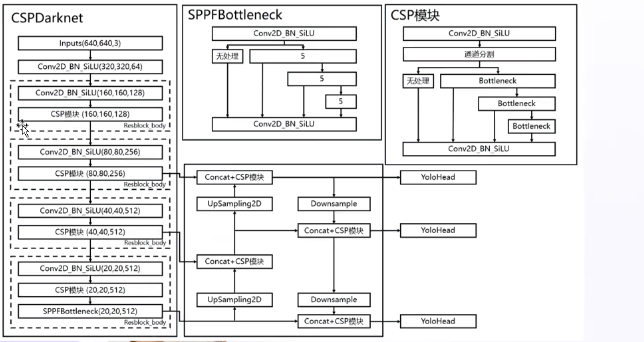
### SiLU激活函数
SiLU 的公式非常简单，就是输入 $x$ 乘以它的 Sigmoid 值：$$f(x) = x \cdot \sigma(x) = x \cdot \frac{1}{1 + e^{-x}}$$
其中 $\sigma(x)$ 是 Sigmoid 函数。本质： SiLU 实际上是 Swish 激活函数的一种特殊情况（当 Swish 的参数 $\beta = 1$ 时）。因此，你在很多文档中会看到它被称为 Swish-1 或直接称为 Swish。